# Multi-Agent Debate — Analysis & Plots

Reads CSVs produced by `analyze.py` and generates paper-ready figures.

**Usage:** Run `python analyze.py --all` first, then run this notebook.

DATA_SUBDIR='analysis' — Found 8 experiments: ['baseline', 'bss', 'dss', 'dbss', 'accuracy_bss', 'binary_bss', 'random_binary', 'random_bss']


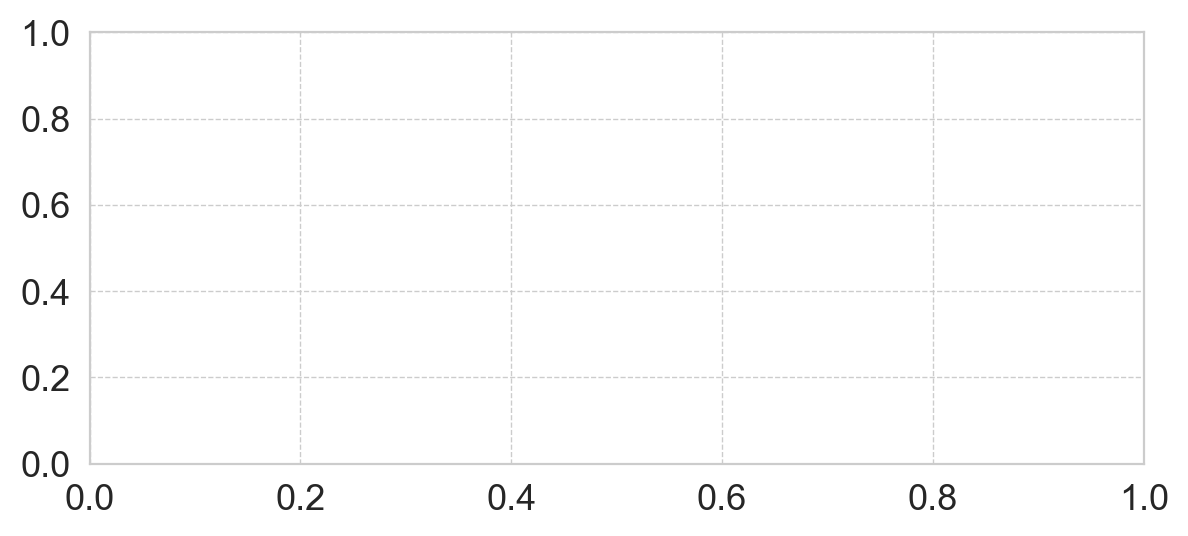

In [10]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import numpy as np
import json, os
from pathlib import Path
from collections import OrderedDict

# ── Style (paper-ready) ───────────────────────────────────────────
plt.rcParams.update({
    # Font (LaTeX-like)
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    
    # Sizes tuned for 1-column figures
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 11,

    # Figure resolution
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",

    # Lines
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.5,
    "lines.linewidth": 1.5,
})

sns.set_style("whitegrid", {
    "grid.linestyle": "--",
    "grid.alpha": 0.3
})

# Distinct hues (DBSS ≠ BSS red; avoid DSS / random_binary both reading as teal)
PALETTE = OrderedDict([
    ("baseline",      "#4A90E2"),
    ("bss",           "#E24A4A"),
    ("dss",           "#50C878"),
    ("dbss",          "#9B59B6"),
    ("accuracy_bss",  "#BCBD22"),
    ("binary_bss",    "#E377C2"),
    ("random_binary", "#696969"),
    ("random_bss",    "#F5A623"),
])
    
fig, ax = plt.subplots(figsize=(6.8, 2.8))  # wide + compact


# plt.rcParams.update({
#     "font.size": 14,
#     "axes.titlesize": 16,
#     "axes.labelsize": 16,
#     "xtick.labelsize": 13,
#     "ytick.labelsize": 13,
#     "legend.fontsize": 12,
#     "figure.dpi": 150,
#     "savefig.dpi": 300,
#     "savefig.bbox": "tight",
# })
# sns.set_style("whitegrid")

# PALETTE = OrderedDict([
#     ("baseline",     "#4A90E2"),
#     ("bss",          "#E24A4A"),
#     ("dss",          "#50C878"),
#     ("binary_bss",   "#F5A623"),
#     ("accuracy_bss", "#9B59B6"),
#     ("random_bss",   "#95A5A6"),
# ])

NICE_NAMES = {
    "baseline": "Baseline",
    "bss": "BSS",
    "dss": "DSS",
    "dbss": "DBSS",
    "binary_bss": "Binary BSS",
    "accuracy_bss": "Accuracy BSS",
    "random_bss": "Random BSS",
    "random_binary": "Random Binary",
}

MODEL_ORDER = ["llama3b", "llama8b", "qwen3b", "qwen7b", "qwen14b", "qwen32b", "majority"]

MODEL_PALETTE = OrderedDict([
    ("llama3b",  "#E24A4A"),
    ("llama8b",  "#F5A623"),
    ("qwen3b",   "#50C878"),
    ("qwen7b",   "#4A90E2"),
    ("qwen14b",  "#9B59B6"),
    ("qwen32b",  "#2C3E50"),
    ("majority", "#95A5A6"),
])

def exp_color(exp):
    return PALETTE.get(exp, "#333333")

def exp_colors(exps):
    return [exp_color(e) for e in exps]

def model_color(model):
    return MODEL_PALETTE.get(model, "#333333")

def model_colors(models):
    return [model_color(m) for m in models]

# ═══════════════════════════════════════════════════════════════════
# CONFIG — edit these paths to point at your data
# ═══════════════════════════════════════════════════════════════════
LOGS_DIR = Path("logs")           # root dir containing experiment folders
FIGS_DIR = Path("figures")        # where plots are saved

# Option 1: auto-discover all experiments that have analysis/ output
# EXPERIMENTS = None

# Option 2: list exactly the experiments you want, in the order you want
# EXPERIMENTS = ["baseline", "bss", "dss"]

# Option 3: point at arbitrary paths (keys become experiment names in plots)
# EXPERIMENT_PATHS = {
#     "baseline_v2": Path("/some/other/place/baseline/analysis"),
#     "bss_250":     Path("logs/bss_250/analysis"),
# }

EXPERIMENTS = None     # set to a list to override auto-discovery
EXPERIMENT_PATHS = {}  # set to a dict to use arbitrary paths
# Subfolder: "analysis" (analyze.py) or "eval" (evaluate.py). Or run the next notebook cell to switch.
DATA_SUBDIR = "analysis"
# ═══════════════════════════════════════════════════════════════════

FIGS_DIR.mkdir(exist_ok=True)

# Legend placement: centered above the axes (heatmap cells keep defaults — no separate legend)
LEGEND_KW = dict(loc="upper center", bbox_to_anchor=(0.5, 1.14), framealpha=0.95)
LEGEND_FIG_KW = dict(loc="upper center", bbox_to_anchor=(0.5, 1.0), framealpha=0.95)

def _marker_csv():
    """Presence of this file under logs/<exp>/<DATA_SUBDIR>/ triggers auto-discovery."""
    return "final_accuracy.csv" if DATA_SUBDIR == "eval" else "accuracy.csv"


# Grouped-bar / legend order (left → right within each model)
EXPERIMENT_ORDER = [
    "baseline", "bss", "dss", "dbss", "accuracy_bss", "binary_bss",
    "random_binary", "random_bss",
]


def _order_experiments(exps):
    """Sort experiment names to match EXPERIMENT_ORDER; unknown names last, then A–Z."""
    rank = {k: i for i, k in enumerate(EXPERIMENT_ORDER)}
    return sorted(exps, key=lambda e: (rank.get(e, 10_000), e))


if EXPERIMENT_PATHS:
    EXPERIMENTS = _order_experiments(list(EXPERIMENT_PATHS.keys()))
elif EXPERIMENTS is None:
    EXPERIMENTS = [d for d in sorted(os.listdir(LOGS_DIR))
                   if (LOGS_DIR / d / DATA_SUBDIR / _marker_csv()).exists()]
    EXPERIMENTS = _order_experiments(EXPERIMENTS)
else:
    EXPERIMENTS = _order_experiments(EXPERIMENTS)


def _data_dir(exp):
    """CSV directory: logs/<exp>/analysis/ or logs/<exp>/eval/."""
    if exp in EXPERIMENT_PATHS:
        return Path(EXPERIMENT_PATHS[exp])
    return LOGS_DIR / exp / DATA_SUBDIR


def _analysis_dir(exp):
    """Backward-compatible alias for _data_dir."""
    return _data_dir(exp)


print(f"DATA_SUBDIR={DATA_SUBDIR!r} — Found {len(EXPERIMENTS)} experiments: {EXPERIMENTS}")


In [11]:
# ── Load CSVs into dicts (analyze.py `analysis/` or evaluate.py `eval/`) ──
accuracy = {}
flips = {}
flip_raw = {}
influence = {}
round_traj = {}
sycophancy = {}
subject_acc = {}
summaries = {}
knowledge_acc = {}
convergence = {}
bss_scores = {}
round1_final = {}
stability = {}
subject_post_syco = {}
subject_flip_dir = {}


def _records_from_jsonl(path: Path) -> list:
    """Same records as analyze.load_log_from_path (no print). Used to build flip_raw when using eval/."""
    records = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            for conv_id, record in obj.items():
                record["conversation_id"] = conv_id
                records.append(record)
    return records


def load_all_csvs():
    """Fill dicts from DATA_SUBDIR. Eval outputs are normalized to match analysis column names."""
    global accuracy, flips, flip_raw, influence, round_traj, sycophancy
    global subject_acc, summaries, knowledge_acc, convergence, bss_scores
    global round1_final, stability, subject_post_syco, subject_flip_dir

    accuracy.clear()
    flips.clear()
    flip_raw.clear()
    influence.clear()
    round_traj.clear()
    sycophancy.clear()
    subject_acc.clear()
    summaries.clear()
    knowledge_acc.clear()
    convergence.clear()
    bss_scores.clear()
    round1_final.clear()
    stability.clear()
    subject_post_syco.clear()
    subject_flip_dir.clear()

    for exp in EXPERIMENTS:
        d = _data_dir(exp)
        if DATA_SUBDIR == "eval":
            accuracy[exp] = pd.read_csv(d / "final_accuracy.csv").rename(
                columns={"final_accuracy": "accuracy"}
            )
            accuracy[exp]["null_rate"] = np.nan
            if "n_samples" in accuracy[exp].columns:
                accuracy[exp]["n_valid"] = accuracy[exp]["n_samples"]

            if (d / "flip_rates.csv").exists():
                flips[exp] = pd.read_csv(d / "flip_rates.csv")

            if (d / "influence.csv").exists():
                influence[exp] = pd.read_csv(d / "influence.csv")

            if (d / "round_accuracy.csv").exists():
                rt = pd.read_csv(d / "round_accuracy.csv")
                if "n_samples" in rt.columns:
                    rt = rt.rename(columns={"n_samples": "n"})
                rt = rt.copy()
                rt["round"] = rt["round"] + 1
                round_traj[exp] = rt

            if (d / "post_sycophancy.csv").exists():
                post = pd.read_csv(d / "post_sycophancy.csv")
                post = post.rename(columns={"post_syco": "syco_rate", "n_samples": "n"})
                sycophancy[exp] = post

            if (d / "per_subject_accuracy.csv").exists():
                subject_acc[exp] = pd.read_csv(d / "per_subject_accuracy.csv")

            if (d / "summary.json").exists():
                with open(d / "summary.json") as f:
                    summaries[exp] = json.load(f)
        else:
            accuracy[exp] = pd.read_csv(d / "accuracy.csv")
            if (d / "flip_summary.csv").exists():
                flips[exp] = pd.read_csv(d / "flip_summary.csv")
            if (d / "flips.csv").exists():
                flip_raw[exp] = pd.read_csv(d / "flips.csv")
            if (d / "influence.csv").exists():
                influence[exp] = pd.read_csv(d / "influence.csv")
            if (d / "round_trajectory.csv").exists():
                round_traj[exp] = pd.read_csv(d / "round_trajectory.csv")
            if (d / "sycophancy_summary.csv").exists():
                sycophancy[exp] = pd.read_csv(d / "sycophancy_summary.csv")
            if (d / "subject_accuracy.csv").exists():
                subject_acc[exp] = pd.read_csv(d / "subject_accuracy.csv")
            if (d / "per_subject_post_sycophancy.csv").exists():
                subject_post_syco[exp] = pd.read_csv(d / "per_subject_post_sycophancy.csv")
            if (d / "per_subject_flip_direction.csv").exists():
                subject_flip_dir[exp] = pd.read_csv(d / "per_subject_flip_direction.csv")
            if (d / "summary.json").exists():
                with open(d / "summary.json") as f:
                    summaries[exp] = json.load(f)
            if (d / "knowledge_gated_accuracy.csv").exists():
                knowledge_acc[exp] = pd.read_csv(d / "knowledge_gated_accuracy.csv")
            if (d / "convergence.csv").exists():
                convergence[exp] = pd.read_csv(d / "convergence.csv")
            bss_path = d / "bss_scores.csv"
            if bss_path.exists():
                try:
                    bss_scores[exp] = pd.read_csv(bss_path)
                except pd.errors.EmptyDataError:
                    pass
            if (d / "round1_vs_final.csv").exists():
                round1_final[exp] = pd.read_csv(d / "round1_vs_final.csv")
            if (d / "stability.csv").exists():
                stability[exp] = pd.read_csv(d / "stability.csv")

    print(f"Loaded ({DATA_SUBDIR!r}).")


load_all_csvs()

Loaded ('analysis').


In [118]:
for exp in EXPERIMENTS:
    print(exp, sorted(accuracy[exp]["model"].tolist()))

baseline ['llama3b', 'llama8b', 'majority', 'qwen14b', 'qwen32b', 'qwen3b', 'qwen7b']
bss ['llama3b', 'llama8b', 'majority', 'qwen14b', 'qwen32b', 'qwen3b', 'qwen7b']
dss ['llama3b', 'llama8b', 'majority', 'qwen14b', 'qwen32b', 'qwen3b', 'qwen7b']
dbss ['llama3b', 'llama8b', 'majority', 'qwen14b', 'qwen32b', 'qwen3b', 'qwen7b']
accuracy_bss ['llama3b', 'llama8b', 'majority', 'qwen14b', 'qwen32b', 'qwen3b', 'qwen7b']
binary_bss ['llama3b', 'llama8b', 'majority', 'qwen14b', 'qwen32b', 'qwen3b', 'qwen7b']
random_binary ['llama3b', 'llama8b', 'majority', 'qwen14b', 'qwen32b', 'qwen3b', 'qwen7b']
random_bss ['llama3b', 'llama8b', 'majority', 'qwen14b', 'qwen32b', 'qwen3b', 'qwen7b']
warning_only ['llama3b', 'llama8b', 'majority', 'qwen14b', 'qwen32b', 'qwen3b', 'qwen7b']


## 1. Cross-Experiment Accuracy Comparison

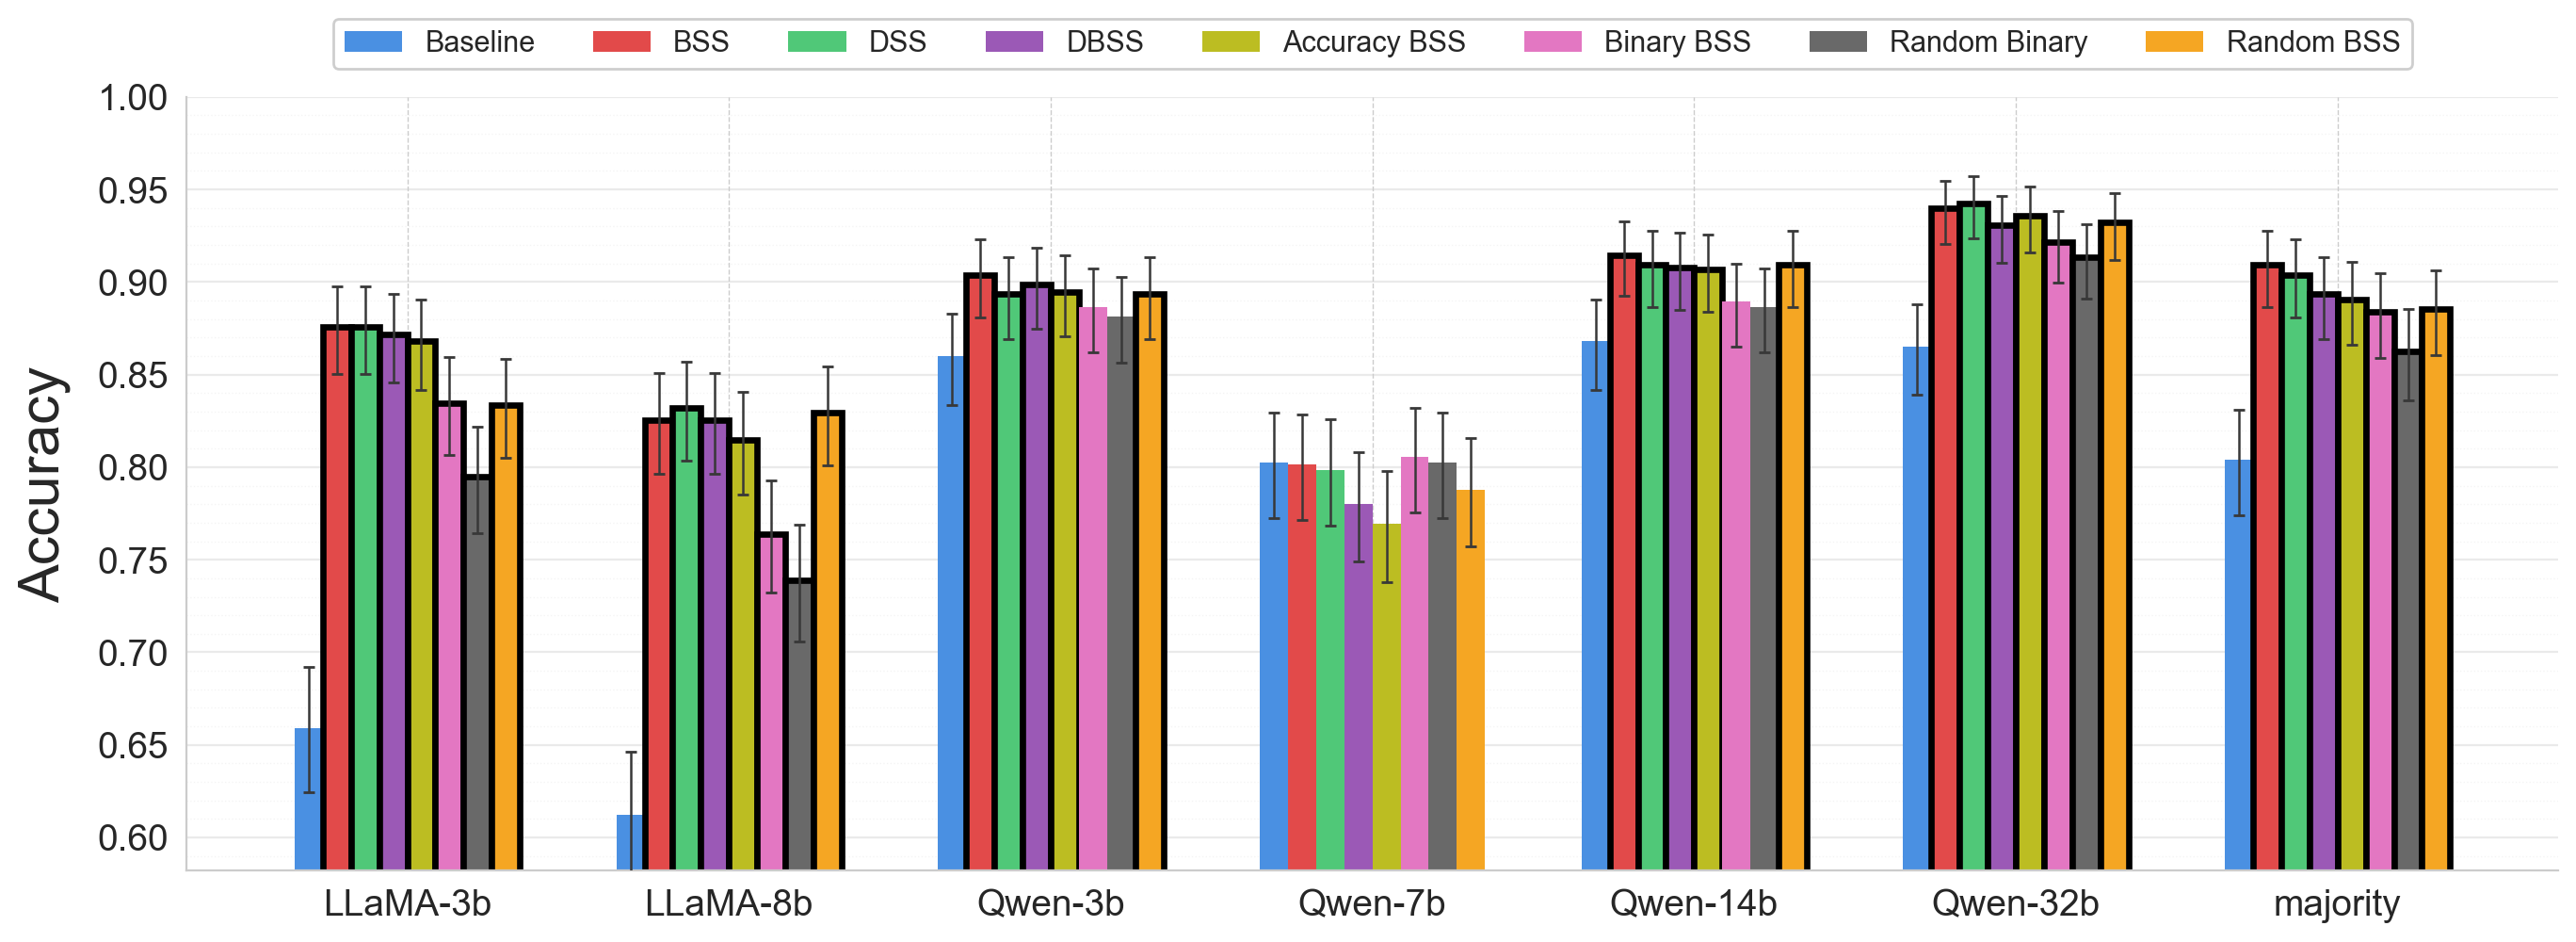

In [16]:
import math

rows = []
for exp in EXPERIMENTS:
    for _, r in accuracy[exp].iterrows():
        row = {
            "experiment": exp,
            "model": r["model"],
            "accuracy": r["accuracy"],
            "null_rate": r["null_rate"],
        }
        if "n_valid" in r.index and pd.notna(r["n_valid"]):
            row["n_valid"] = int(r["n_valid"])
        else:
            row["n_valid"] = np.nan
        nv = row["n_valid"]
        acc = float(row["accuracy"]) if pd.notna(row["accuracy"]) else np.nan
        # Exact count of correct non-null answers (per question / sample); required for binomial CIs
        if "n_correct" in r.index and pd.notna(r["n_correct"]):
            row["n_correct"] = int(r["n_correct"])
        elif pd.notna(nv) and nv > 0 and np.isfinite(acc):
            row["n_correct"] = int(round(acc * int(nv)))
        else:
            row["n_correct"] = np.nan
        rows.append(row)

comp_df = pd.DataFrame(rows)
comp_df["model"] = pd.Categorical(comp_df["model"], categories=MODEL_ORDER, ordered=True)
comp_df = comp_df.sort_values(["model", "experiment"])

# Bar height = k/n (exact when n_correct is present)
_nv = comp_df["n_valid"].astype(float)
_nc = comp_df["n_correct"]
comp_df["p_hat"] = np.where(
    _nc.notna() & np.isfinite(_nv) & (_nv > 0),
    _nc.astype(float) / _nv,
    comp_df["accuracy"].astype(float),
)


def _wilson_95_ci(k, n):
    """Wilson score 95% CI for binomial proportion k/n (clipped to [0, 1])."""
    n = int(n)
    if n <= 0:
        return np.nan, np.nan
    k = float(k)
    k = min(max(k, 0.0), float(n))
    p_hat = k / n
    z = 1.959963984540054
    z2 = z * z
    denom = 1.0 + z2 / n
    center = (p_hat + z2 / (2.0 * n)) / denom
    rad = z * np.sqrt((p_hat * (1.0 - p_hat) + z2 / (4.0 * n)) / n) / denom
    return float(max(0.0, center - rad)), float(min(1.0, center + rad))


def _ci_errors_for_bar(n_valid, n_correct):
    """Asymmetric yerr from Wilson CI; uses exact k, n from per-answer binary counts."""
    if pd.isna(n_valid) or int(n_valid) <= 0 or pd.isna(n_correct):
        return 0.0, 0.0, np.nan
    n_v = int(n_valid)
    k = int(n_correct)
    k = min(max(k, 0), n_v)
    p_hat = k / n_v
    lo, hi = _wilson_95_ci(k, n_v)
    if np.isnan(lo) or np.isnan(hi):
        return 0.0, 0.0, p_hat
    return float(p_hat - lo), float(hi - p_hat), p_hat


def _two_prop_z_pvalue(k1, n1, k2, n2):
    """Two-sided p-value for H0: p1 = p2 (pooled SE two-proportion z-test)."""
    n1, n2 = float(n1), float(n2)
    if n1 <= 0 or n2 <= 0:
        return np.nan
    k1, k2 = float(k1), float(k2)
    p1, p2 = k1 / n1, k2 / n2
    p_pool = (k1 + k2) / (n1 + n2)
    if p_pool <= 0 or p_pool >= 1:
        return np.nan
    se = np.sqrt(p_pool * (1.0 - p_pool) * (1.0 / n1 + 1.0 / n2))
    if se == 0 or not np.isfinite(se):
        return np.nan
    z = (p1 - p2) / se
    az = abs(z)
    phi_az = 0.5 * (1.0 + math.erf(az / math.sqrt(2.0)))
    return float(2.0 * (1.0 - phi_az))


baseline_name = "baseline" if "baseline" in EXPERIMENTS else None
base_df = None
if baseline_name is not None:
    base_df = comp_df[comp_df["experiment"] == baseline_name].set_index("model")


def _sig_vs_baseline(row, model):
    """True if accuracy differs from baseline (same model) at p<0.05 (two-proportion z-test)."""
    if base_df is None or model not in base_df.index:
        return False
    br = base_df.loc[model]
    n_b = br["n_valid"]
    n_e = row["n_valid"]
    if pd.isna(n_b) or pd.isna(n_e) or int(n_b) <= 0 or int(n_e) <= 0:
        return False
    n_b = int(n_b)
    n_e = int(n_e)
    k_b = int(br["n_correct"]) if pd.notna(br["n_correct"]) else int(round(float(br["accuracy"]) * n_b))
    k_e = int(row["n_correct"]) if pd.notna(row["n_correct"]) else int(round(float(row["accuracy"]) * n_e))
    k_b = min(max(k_b, 0), n_b)
    k_e = min(max(k_e, 0), n_e)
    p = _two_prop_z_pvalue(k_e, n_e, k_b, n_b)
    return bool(np.isfinite(p) and p < 0.05)


fig, ax = plt.subplots(figsize=(14, 6.5))
models_in_data = [m for m in MODEL_ORDER if m in comp_df["model"].unique()]
x = np.arange(len(models_in_data))
n_exp = len(EXPERIMENTS)
width = 0.7 / n_exp

err_kw = dict(ecolor="0.22", elinewidth=0.9, capsize=2.2, zorder=3)

for i, exp in enumerate(EXPERIMENTS):
    exp_data = comp_df[comp_df["experiment"] == exp].set_index("model")
    vals = []
    err_lo = []
    err_hi = []
    edgecolors = []
    linewidths = []
    for m in models_in_data:
        if m not in exp_data.index:
            vals.append(np.nan)
            err_lo.append(0.0)
            err_hi.append(0.0)
            edgecolors.append("none")
            linewidths.append(0.0)
            continue
        row = exp_data.loc[m]
        n_v = row["n_valid"]
        nc = row["n_correct"]
        el, eh, p_hat = _ci_errors_for_bar(n_v, nc)
        vals.append(p_hat)
        err_lo.append(el)
        err_hi.append(eh)
        if baseline_name is None or exp == baseline_name:
            edgecolors.append("none")
            linewidths.append(0.0)
        elif _sig_vs_baseline(row, m):
            edgecolors.append("black")
            linewidths.append(2.4)
        else:
            edgecolors.append("none")
            linewidths.append(0.0)

    bars = ax.bar(
        x + i * width,
        vals,
        width,
        yerr=[err_lo, err_hi],
        label=NICE_NAMES.get(exp, exp),
        color=exp_color(exp),
        edgecolor="none",
        linewidth=0,
        error_kw=err_kw,
    )
    for patch, ec, lw in zip(bars.patches, edgecolors, linewidths):
        patch.set_edgecolor(ec)
        patch.set_linewidth(lw)

_ymin = max(0.0, float(np.nanmin(comp_df["p_hat"].to_numpy())) - 0.03)
ax.set_ylim(_ymin, 1.0)

ax.set_ylabel("Accuracy", fontsize=22, labelpad=10)
ax.set_xticks(x + width * (n_exp - 1) / 2)
ax.set_xticklabels([m.replace("llama", "LLaMA-").replace("qwen", "Qwen-") for m in models_in_data], fontsize=14)

ax.tick_params(labelsize=14)

ax.yaxis.set_major_locator(plt.MultipleLocator(0.05))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.01))

ax.grid(True, which="major", axis="y", linestyle="-", alpha=0.4, linewidth=0.8, zorder=0)
ax.grid(True, which="minor", axis="y", linestyle=":", alpha=0.2, linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

sns.despine(left=False, bottom=False)

leg = ax.legend(ncol=len(EXPERIMENTS), loc="upper center", bbox_to_anchor=(0.5, 1.12), framealpha=0.95)
for patch in leg.legend_handles:
    patch.set_edgecolor("none")
    patch.set_linewidth(0)
fig.tight_layout(rect=[0, 0, 1, 0.82])
fig.savefig(FIGS_DIR / "accuracy_comparison.pdf")
fig.savefig(FIGS_DIR / "accuracy_comparison.png")
plt.show()


In [17]:
# Print the numbers as a clean table
pivot = comp_df.pivot_table(index="experiment", columns="model", values="accuracy")
_prow = [e for e in EXPERIMENT_ORDER if e in pivot.index]
_extra = [e for e in pivot.index if e not in EXPERIMENT_ORDER]
pivot = pivot.reindex(_prow + sorted(_extra))
pivot = pivot[[m for m in MODEL_ORDER if m in pivot.columns]]
# Rename columns to match chart labels
pivot.columns = [c.replace("llama", "LLaMA-").replace("qwen", "Qwen-") for c in pivot.columns]
pivot.index.name = None  # Remove the "experiment" label from the index
display(pivot.round(4).style.background_gradient(cmap="RdYlGn", axis=None, vmin=0.6, vmax=1.0))

/var/folders/h3/d4qhj3nn6j505hsm3ks5sr540000gn/T/ipykernel_33781/4237203391.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = comp_df.pivot_table(index="experiment", columns="model", values="accuracy")


,LLaMA-3b,LLaMA-8b,Qwen-3b,Qwen-7b,Qwen-14b,Qwen-32b,majority
baseline,0.659100,0.612000,0.860000,0.802700,0.868000,0.865300,0.804000
bss,0.875800,0.825300,0.904000,0.801300,0.914700,0.940000,0.909300
dss,0.875800,0.832000,0.893300,0.798700,0.909300,0.942700,0.904000
dbss,0.871700,0.825300,0.898700,0.780000,0.908000,0.930700,0.893300
accuracy_bss,0.868000,0.814700,0.894700,0.769300,0.906700,0.936000,0.890700
binary_bss,0.834700,0.764000,0.886700,0.805300,0.889300,0.921300,0.884000
random_binary,0.794700,0.738700,0.881300,0.802700,0.886700,0.913300,0.862700
random_bss,0.833300,0.829300,0.893300,0.788000,0.909300,0.932000,0.885300


## 4. Influence Heatmaps

/var/folders/h3/d4qhj3nn6j505hsm3ks5sr540000gn/T/ipykernel_5707/185964819.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.04, 0.06, 0.98, 0.94])


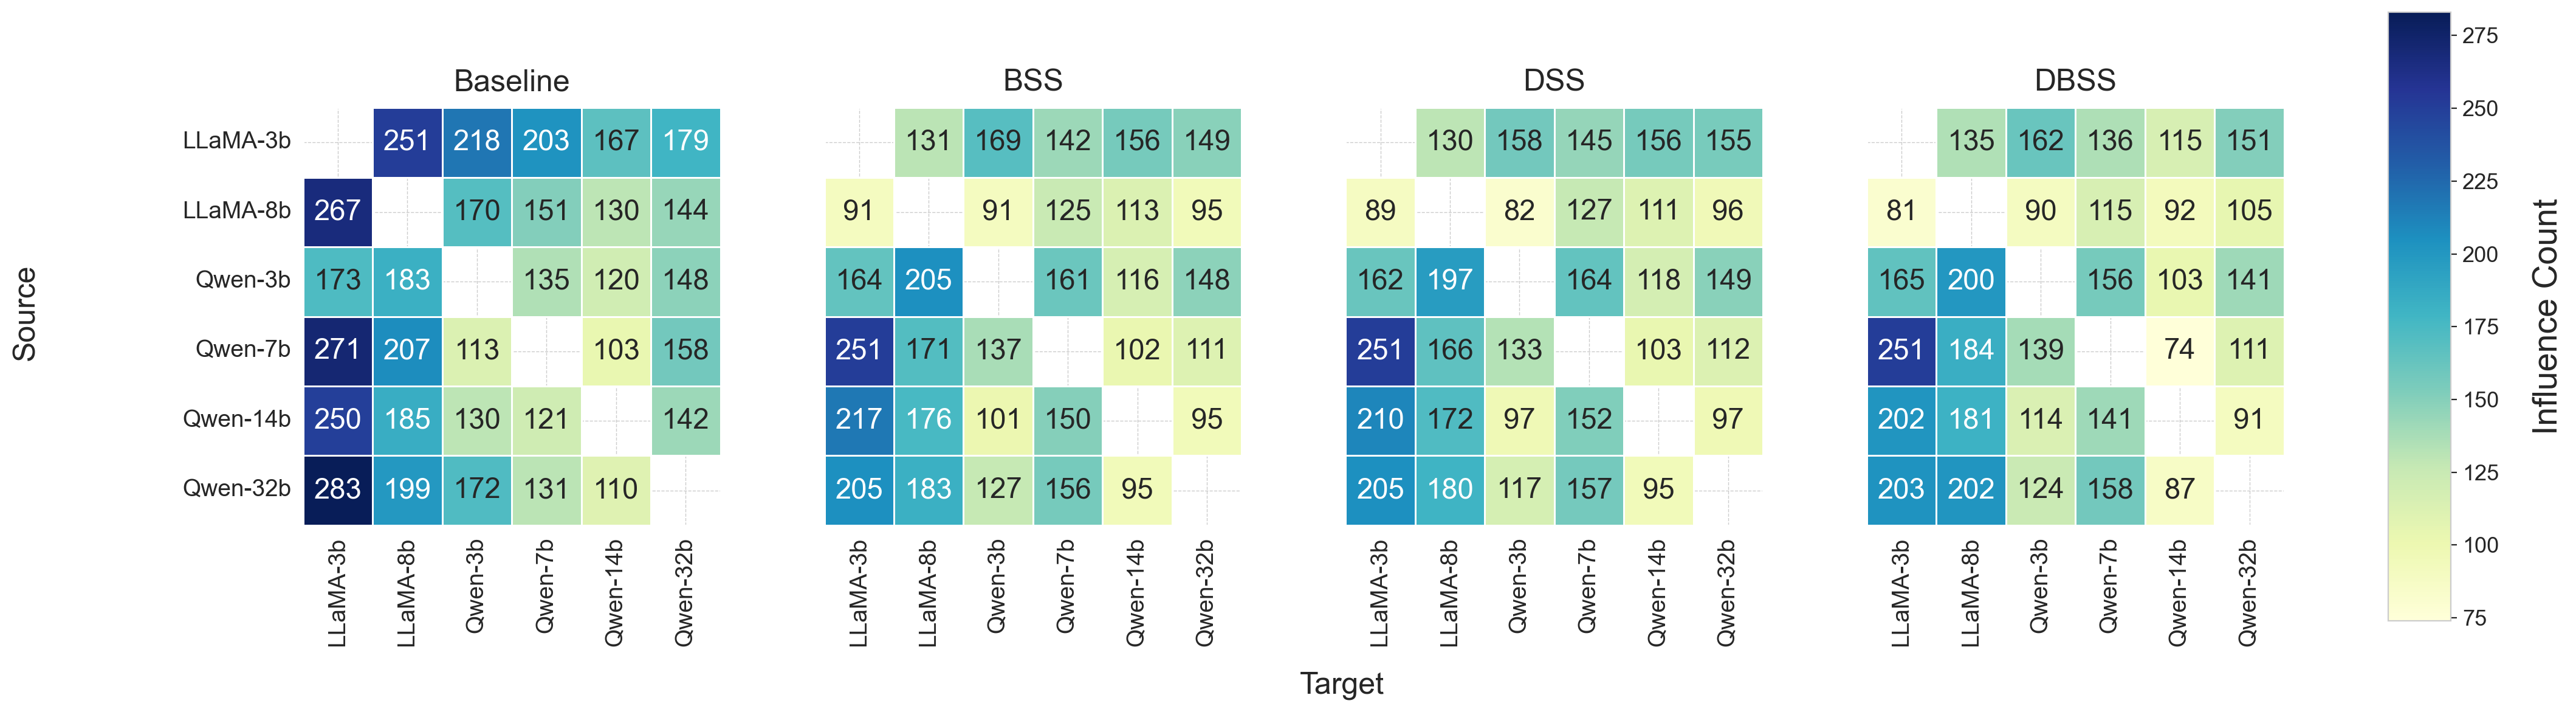

/var/folders/h3/d4qhj3nn6j505hsm3ks5sr540000gn/T/ipykernel_5707/185964819.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.04, 0.06, 0.98, 0.94])


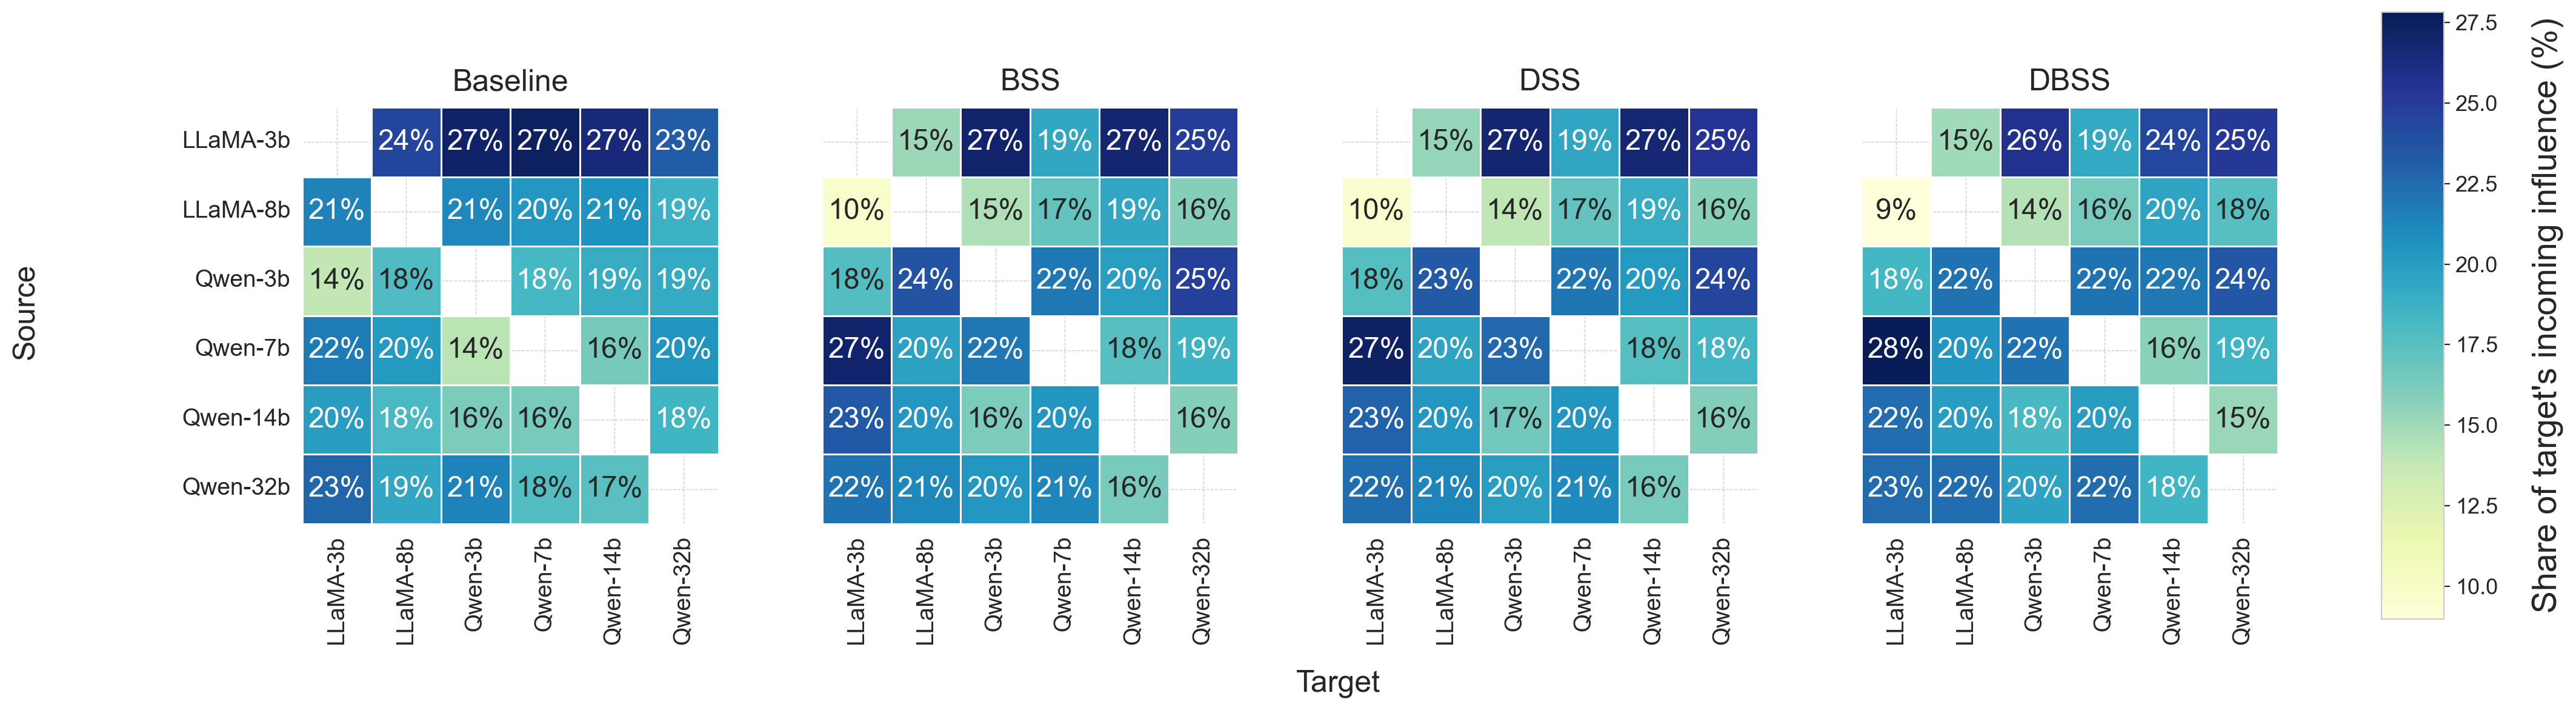

/var/folders/h3/d4qhj3nn6j505hsm3ks5sr540000gn/T/ipykernel_5707/185964819.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.04, 0.06, 0.98, 0.94])


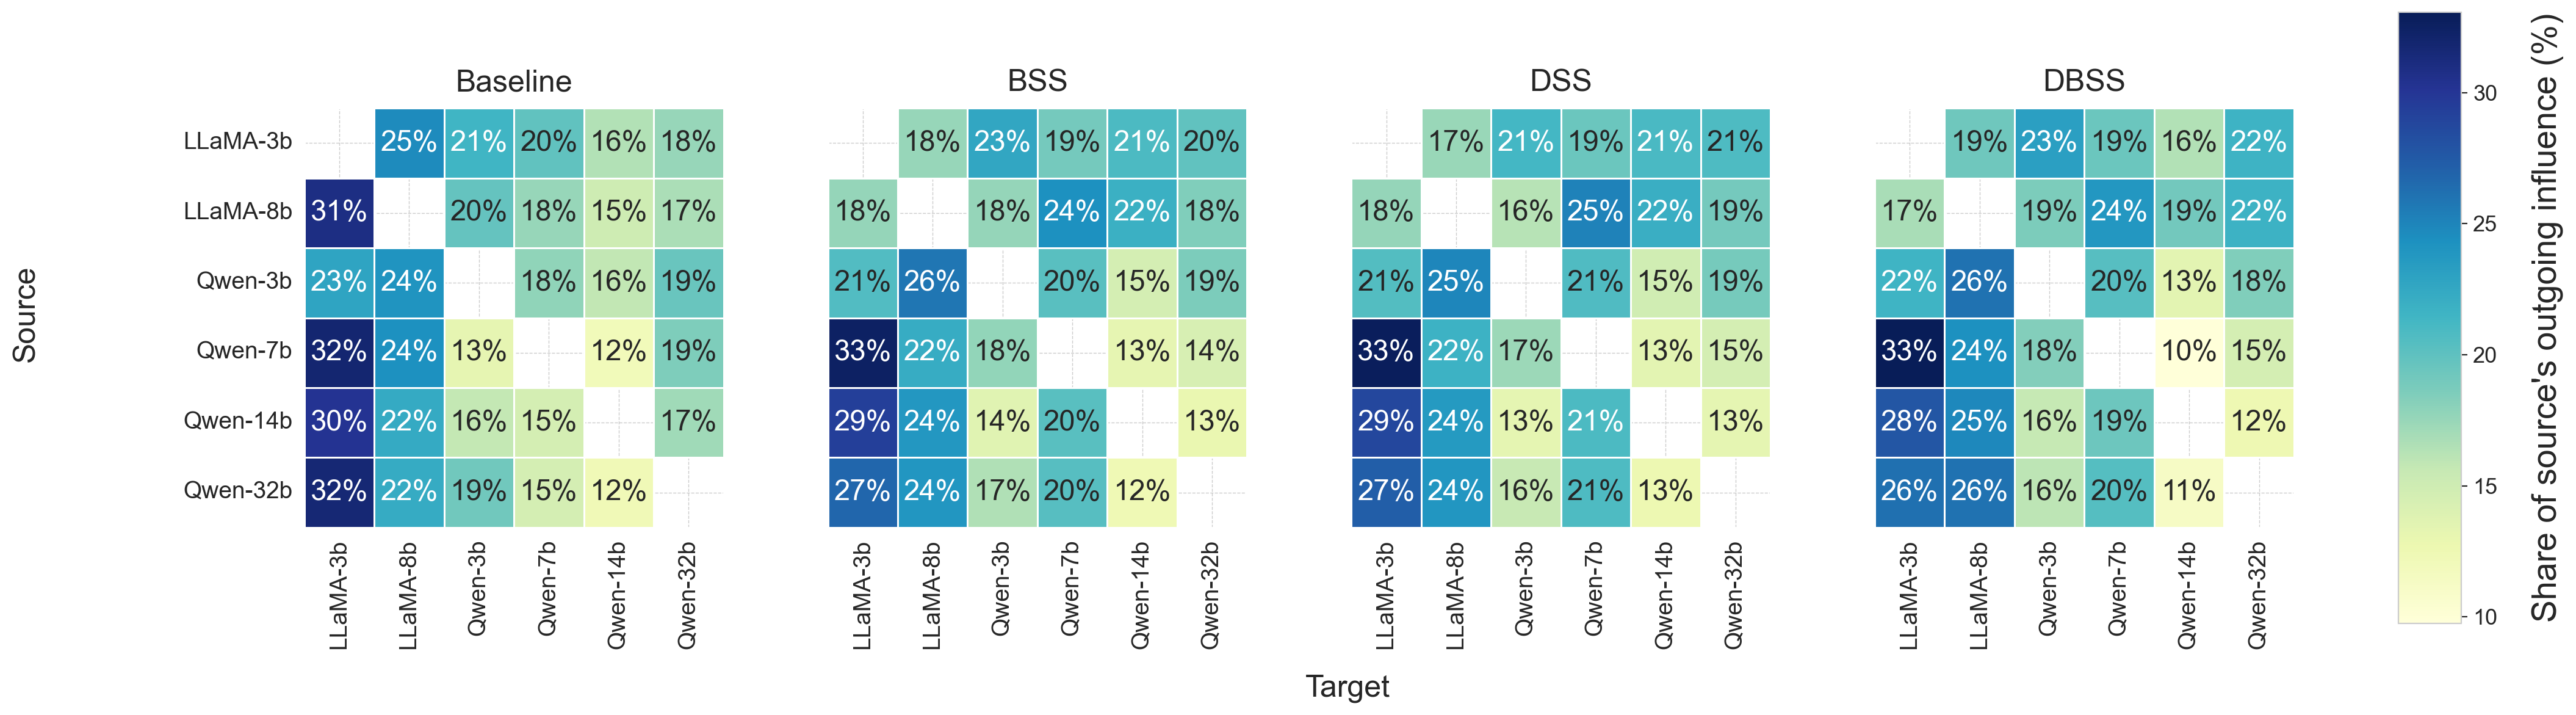

In [8]:
preferred = ["baseline", "bss", "dss", "dbss"]
exps_to_show = [e for e in preferred if e in influence]
if not exps_to_show:
    exps_to_show = [e for e in EXPERIMENTS if e in influence][:3]

from matplotlib.gridspec import GridSpec


def _influence_col_pct(mat):
    """Per target (column): % of that target's incoming influence from each source."""
    if mat is None:
        return None
    m = mat.astype(float)
    out = m.copy()
    for c in m.columns:
        tot = np.nansum(m[c].to_numpy())
        if tot > 0:
            out[c] = m[c] / tot * 100.0
        else:
            out[c] = np.nan
    return out


def _influence_row_pct(mat):
    """Per source (row): % of that source's outgoing influence to each target."""
    if mat is None:
        return None
    m = mat.astype(float)
    out = m.copy()
    for r in m.index:
        tot = np.nansum(m.loc[r].to_numpy())
        if tot > 0:
            out.loc[r] = m.loc[r] / tot * 100.0
        else:
            out.loc[r] = np.nan
    return out


if exps_to_show:
    # Build matrices and a common model order + color scale
    matrices = []
    models_union = []
    for exp in exps_to_show:
        idf = influence[exp]
        if idf.empty:
            matrices.append(None)
            continue
        ml = sorted(set(idf["source"]) | set(idf["target"]))
        ml = [m for m in MODEL_ORDER if m in ml and m != "majority"]
        models_union.extend(ml)
        mat = pd.DataFrame(np.nan, index=ml, columns=ml)
        for _, r in idf.iterrows():
            if r["source"] in ml and r["target"] in ml:
                mat.loc[r["source"], r["target"]] = r["count"]
        for i, m in enumerate(ml):
            mat.iloc[i, i] = np.nan  # no self-influence on diagonal
        matrices.append(mat)

    models_list = [m for m in MODEL_ORDER if m in set(models_union) and m != "majority"]
    for j in range(len(matrices)):
        if matrices[j] is None:
            continue
        matrices[j] = matrices[j].reindex(index=models_list, columns=models_list)

    vals = np.concatenate([m.values.ravel() for m in matrices if m is not None])
    vals = vals[~np.isnan(vals)]
    vmin, vmax = (float(vals.min()), float(vals.max())) if len(vals) else (0.0, 1.0)

    matrices_pct = [_influence_col_pct(m) for m in matrices]
    pct_parts = [m.values.ravel() for m in matrices_pct if m is not None]
    pct_flat = np.concatenate(pct_parts) if pct_parts else np.array([])
    pct_flat = pct_flat[~np.isnan(pct_flat)]
    if len(pct_flat):
        vmin_p, vmax_p = float(pct_flat.min()), float(pct_flat.max())
    else:
        vmin_p, vmax_p = 0.0, 100.0
    if vmin_p >= vmax_p:
        vmin_p, vmax_p = 0.0, 100.0

    matrices_row_pct = [_influence_row_pct(m) for m in matrices]
    row_parts = [m.values.ravel() for m in matrices_row_pct if m is not None]
    row_flat = np.concatenate(row_parts) if row_parts else np.array([])
    row_flat = row_flat[~np.isnan(row_flat)]
    if len(row_flat):
        vmin_r, vmax_r = float(row_flat.min()), float(row_flat.max())
    else:
        vmin_r, vmax_r = 0.0, 100.0
    if vmin_r >= vmax_r:
        vmin_r, vmax_r = 0.0, 100.0

    n = len(exps_to_show)

    def _plot_influence_grid(mat_list, v0, v1, stem, cbar_label, pct_annot=False):
        fig = plt.figure(figsize=(5.4 * n + 1.2, 6.5))
        gs = GridSpec(1, n + 1, figure=fig, width_ratios=[1] * n + [0.15], wspace=0.30)
        axes = [fig.add_subplot(gs[0, j]) for j in range(n)]
        cax = fig.add_subplot(gs[0, n])
        cbar_mappable = None

        for idx, exp in enumerate(exps_to_show):
            ax = axes[idx]
            mat = mat_list[idx]
            if mat is None:
                ax.set_axis_off()
                continue
            data = mat.astype(float).values
            mask = np.isnan(data)
            if pct_annot:
                annot = np.empty(data.shape, dtype=object)
                for i in range(data.shape[0]):
                    for j in range(data.shape[1]):
                        if mask[i, j]:
                            annot[i, j] = ""
                        else:
                            annot[i, j] = f"{data[i, j]:.0f}%"
                hm = sns.heatmap(
                    mat.astype(float),
                    ax=ax,
                    annot=annot,
                    fmt="",
                    cmap="YlGnBu",
                    mask=mask,
                    linewidths=1,
                    linecolor="white",
                    square=True,
                    annot_kws={"size": 17},
                    vmin=v0,
                    vmax=v1,
                    cbar=False,
                )
            else:
                hm = sns.heatmap(
                    mat.astype(float),
                    ax=ax,
                    annot=True,
                    fmt=".0f",
                    cmap="YlGnBu",
                    mask=mask,
                    linewidths=1,
                    linecolor="white",
                    square=True,
                    annot_kws={"size": 17},
                    vmin=v0,
                    vmax=v1,
                    cbar=False,
                )
            cbar_mappable = hm.collections[0]
            ax.set_title(NICE_NAMES.get(exp, exp), fontsize=18, pad=10)
            ax.set_xlabel("")
            ax.set_ylabel("")

            x_labels = [
                label.get_text().replace("llama", "LLaMA-").replace("qwen", "Qwen-")
                for label in ax.get_xticklabels()
            ]
            y_labels = [
                label.get_text().replace("llama", "LLaMA-").replace("qwen", "Qwen-")
                for label in ax.get_yticklabels()
            ]
            ax.set_xticklabels(x_labels, fontsize=14, rotation=90, ha="center")

            if idx == 0:
                ax.set_yticklabels(y_labels, fontsize=14)
            else:
                ax.set_yticklabels([])

        fig.supylabel("Source", fontsize=18, x=0.02)
        fig.supxlabel("Target", fontsize=18, y=0.01)

        if cbar_mappable is not None:
            cbar = fig.colorbar(cbar_mappable, cax=cax)
            cbar.set_label(cbar_label, fontsize=20, labelpad=20)
            cbar.ax.tick_params(labelsize=13)

        fig.tight_layout(rect=[0.04, 0.06, 0.98, 0.94])
        fig.savefig(FIGS_DIR / f"{stem}.pdf")
        fig.savefig(FIGS_DIR / f"{stem}.png")
        plt.show()

    _plot_influence_grid(
        matrices, vmin, vmax, "influence_heatmaps", "Influence Count", pct_annot=False
    )
    _plot_influence_grid(
        matrices_pct,
        vmin_p,
        vmax_p,
        "influence_heatmaps_pct",
        "Share of target's incoming influence (%)",
        pct_annot=True,
    )
    _plot_influence_grid(
        matrices_row_pct,
        vmin_r,
        vmax_r,
        "influence_heatmaps_row_pct",
        "Share of source's outgoing influence (%)",
        pct_annot=True,
    )


## 5. Round-by-Round Accuracy Trajectory

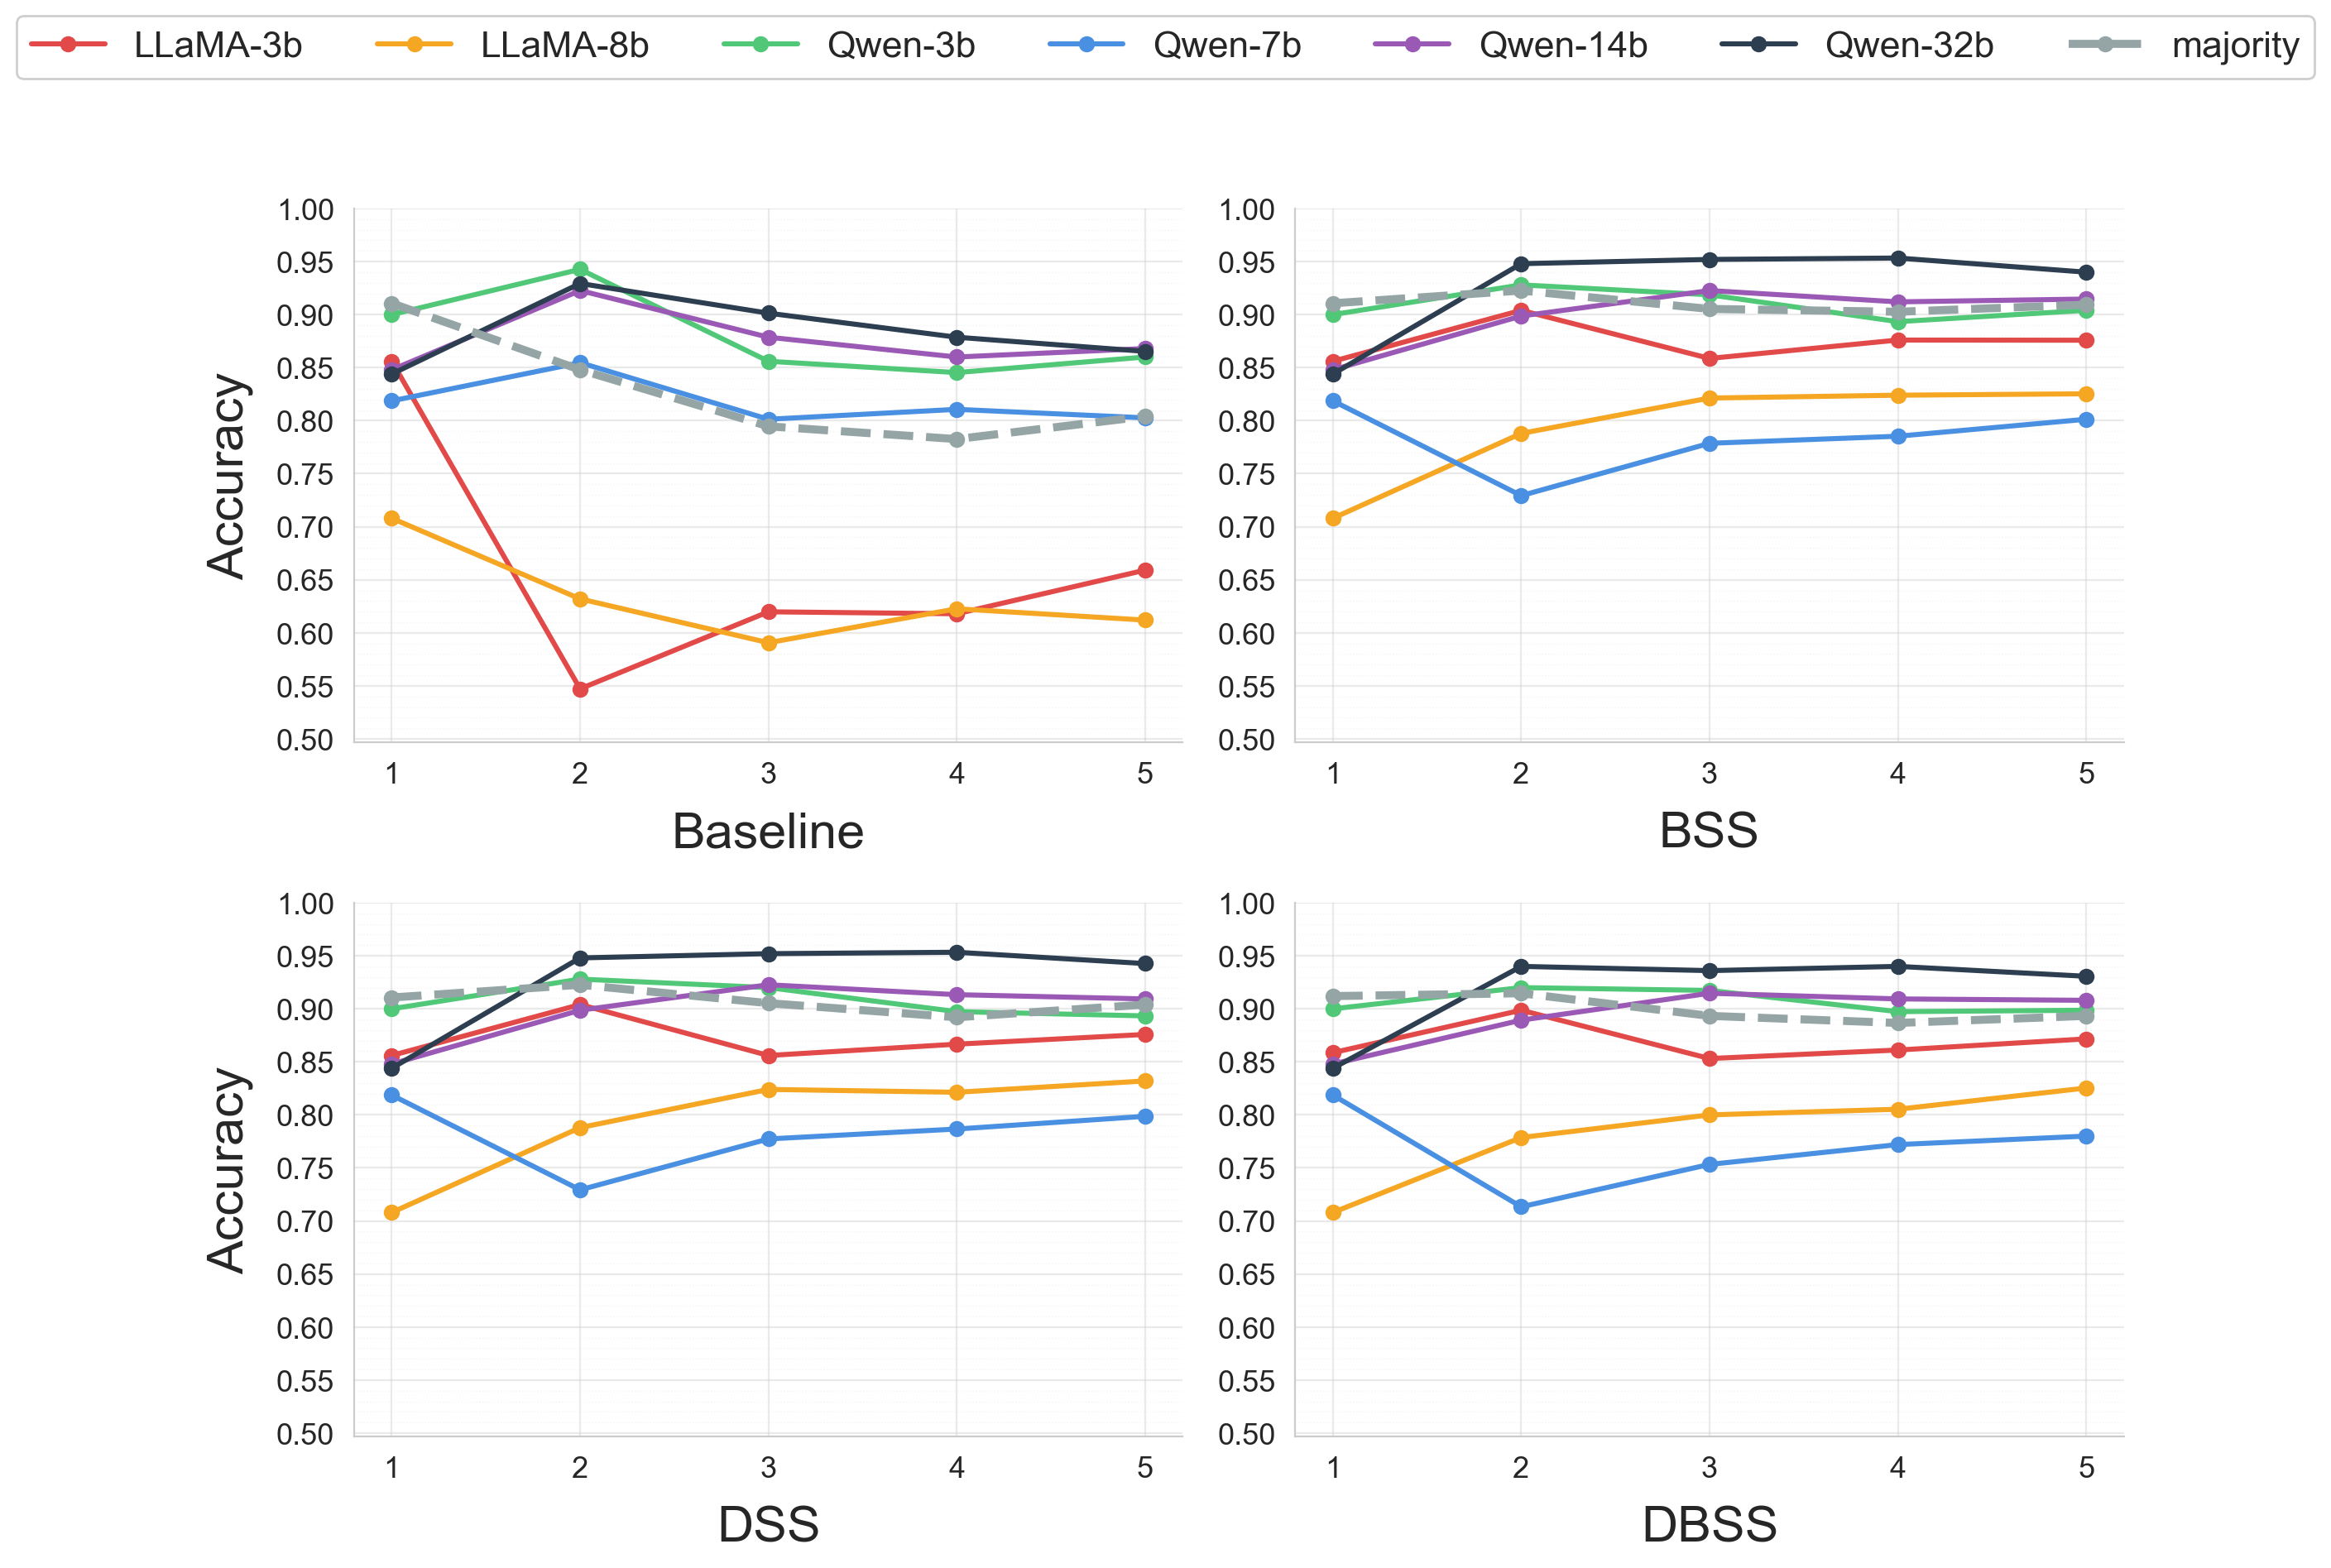

In [9]:
exps_traj = [e for e in ["baseline", "bss", "dss", "dbss"] if e in round_traj]
if not exps_traj:
    exps_traj = list(round_traj.keys())[:4]

if exps_traj:
    _n_traj = len(exps_traj)
    _nr, _nc = 1, 4
    _figsize = (20, 5.2)
    fig, axes = plt.subplots(_nr, _nc, figsize=_figsize, squeeze=False)
    axes_flat = axes.flatten()
    for _j in range(_n_traj, len(axes_flat)):
        axes_flat[_j].set_visible(False)
    _acc_parts = [
        pd.to_numeric(round_traj[e]["accuracy"], errors="coerce").to_numpy()
        for e in exps_traj if e in round_traj and not round_traj[e].empty
    ]
    _all_acc = np.concatenate(_acc_parts) if _acc_parts else np.array([])
    if _all_acc.size:
        _mn = np.nanmin(_all_acc)
        _traj_ymin = max(0.0, float(_mn) - 0.05) if np.isfinite(_mn) else 0.5
    else:
        _traj_ymin = 0.5

    for idx, exp in enumerate(exps_traj):
        ax = axes_flat[idx]
        df = round_traj[exp]
        for model in MODEL_ORDER:
            mdf = df[df["model"] == model]
            if mdf.empty:
                continue
            ls = "--" if model == "majority" else "-"
            lw = 3.5 if model == "majority" else 2.2  # Sharper, thicker lines
            model_display = model.replace("llama", "LLaMA-").replace("qwen", "Qwen-")
            ax.plot(mdf["round"], mdf["accuracy"], ls, lw=lw, label=model_display,
                    marker="o", ms=6, color=model_color(model), antialiased=True)
        
        ax.set_xlabel(NICE_NAMES.get(exp, exp), fontsize=22, labelpad=10)
        ax.set_ylabel("Accuracy" if idx % _nc == 0 else "", fontsize=22, labelpad=10)
        ax.set_ylim(_traj_ymin, 1.0)
        
        # Fine-grained y-axis ticks (0.05 intervals for better granularity)
        ax.yaxis.set_major_locator(plt.MultipleLocator(0.05))
        ax.yaxis.set_minor_locator(plt.MultipleLocator(0.01))
        
        # Add minor gridlines for better readability
        ax.grid(True, which="major", alpha=0.4, linestyle="-", linewidth=0.8, zorder=0)
        ax.grid(True, which="minor", alpha=0.2, linestyle=":", linewidth=0.5, zorder=0)
        ax.set_axisbelow(True)
        
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.tick_params(labelsize=13, length=5, width=1.2)

    handles, labels = axes_flat[_n_traj - 1].get_legend_handles_labels()
    # Lower the 2nd value in bbox_to_anchor to move legend down (1 = top of figure).
    fig.legend(
        handles, labels, ncol=len(handles), fontsize=16,
        loc="upper center", bbox_to_anchor=(0.5, 0.96), framealpha=0.95,
    )

    for _iax in range(_n_traj):
        sns.despine(ax=axes_flat[_iax])
    fig.tight_layout(rect=[0, 0, 1, 0.86])
    fig.savefig(FIGS_DIR / "round_trajectory.pdf")
    fig.savefig(FIGS_DIR / "round_trajectory.png")
    plt.show()


## 6. Post-Discussion Sycophancy

Cross-experiment figure: metric **`sycophant_with_knowledge`** (edit `SYCO_METRIC_BAR` in the plot cell to change). **95% Wilson** intervals, **thick black outline** vs Baseline at *p*<0.05 (two-proportion *z*-test) — same statistical layer as §1.


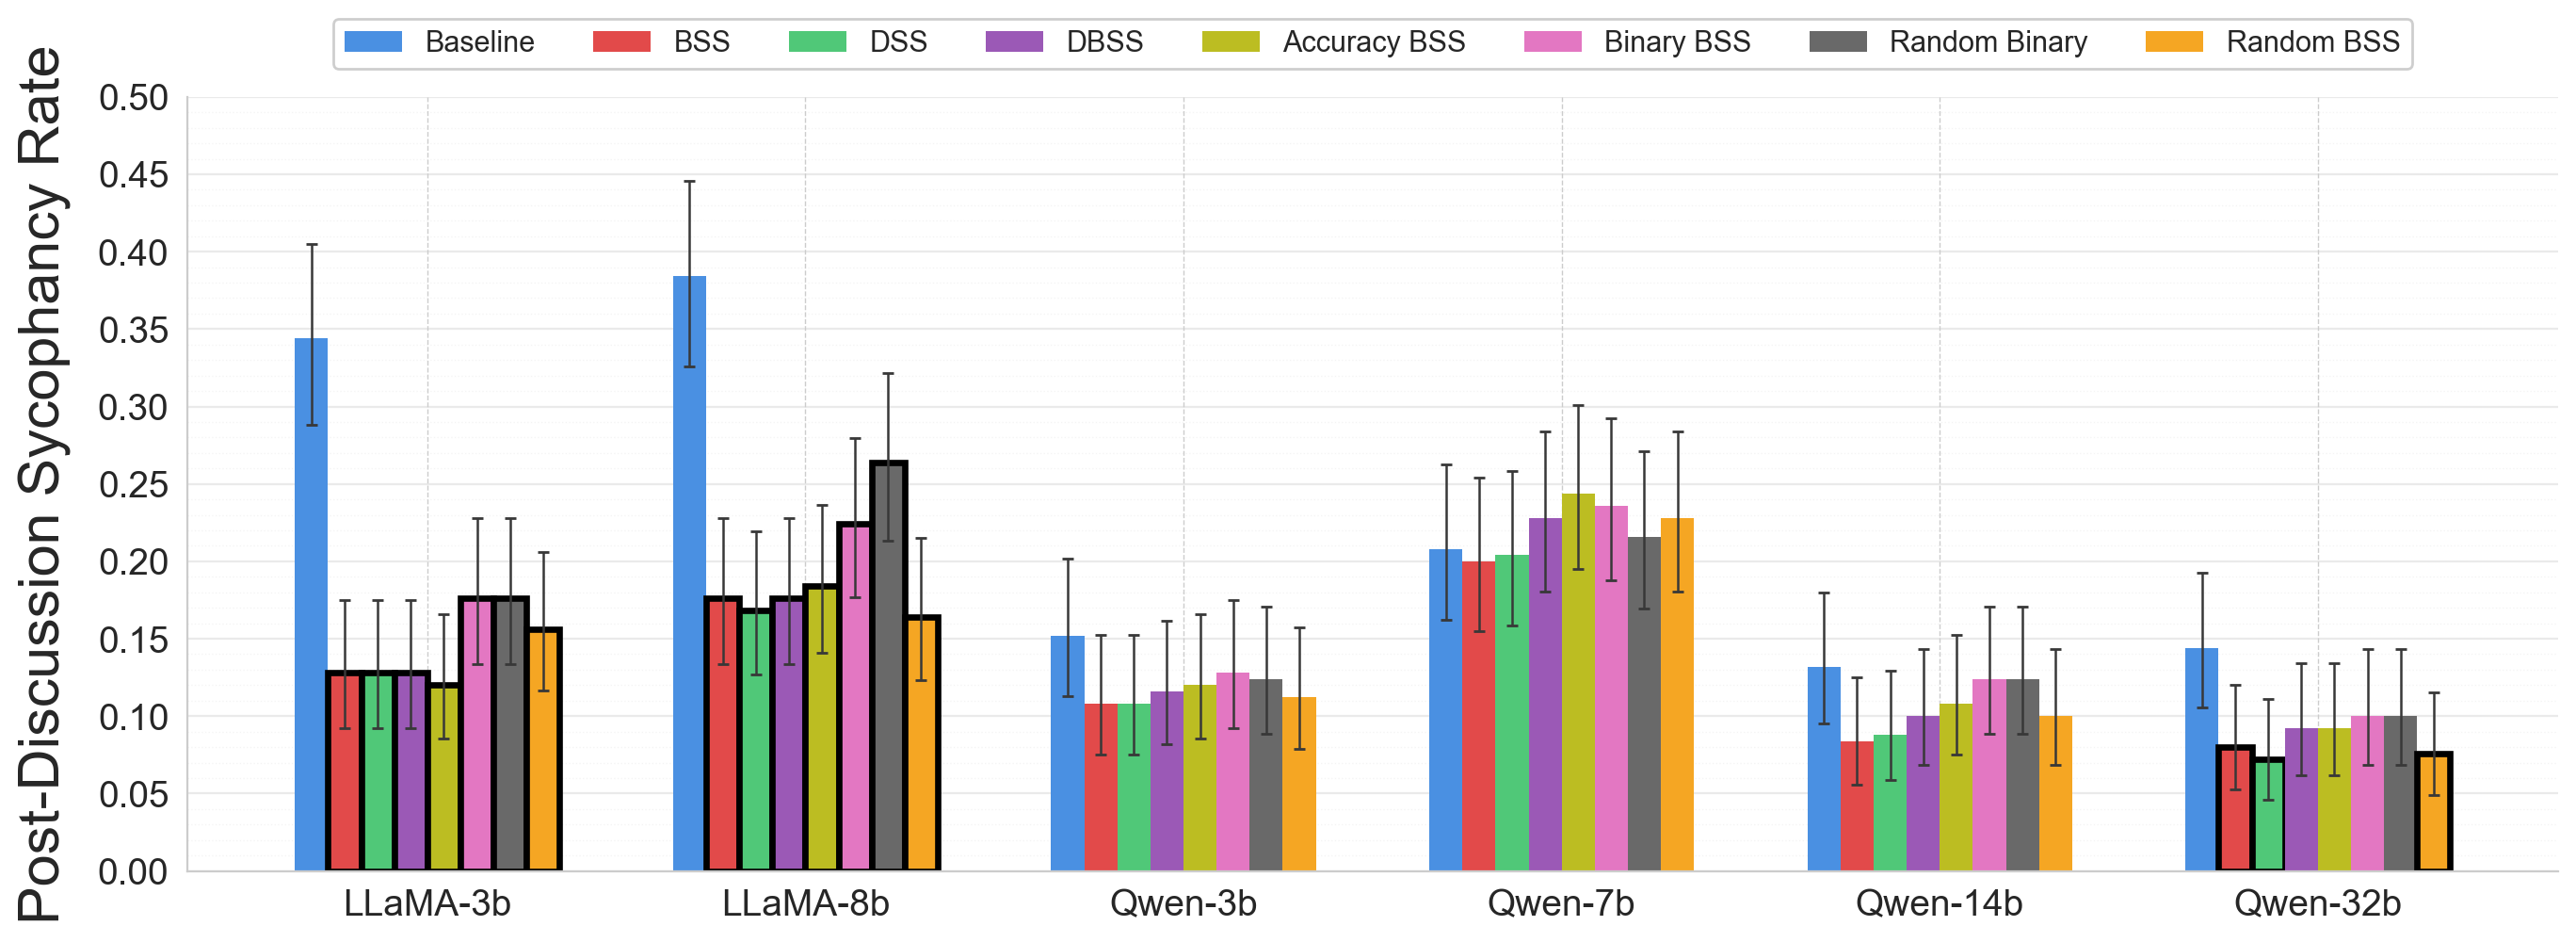

In [21]:
# Same statistical layer as §1 (accuracy): Wilson 95% CIs + thick black edge if p<0.05 vs Baseline
# (two-proportion z-test). Uses one metric so k/n is well-defined.
SYCO_METRIC_BAR = "sycophant_with_knowledge"

syco_rows = []
for exp in EXPERIMENTS:
    if exp in sycophancy:
        df = sycophancy[exp].copy()
        df["experiment"] = exp
        syco_rows.append(df)

if syco_rows:
    all_syco = pd.concat(syco_rows, ignore_index=True)
    if "metric" not in all_syco.columns:
        raise ValueError(
            "sycophancy table has no 'metric' column — use analyze.py outputs (sycophancy_summary.csv) "
            "or eval post_sycophancy with metric."
        )
    plot_syco = all_syco[all_syco["metric"] == SYCO_METRIC_BAR].copy()
    if plot_syco.empty:
        print(f"No rows for metric={SYCO_METRIC_BAR!r}; skip sycophancy comparison plot.")
    else:
        import math

        def _wilson_95_ci(k, n):
            """Wilson score 95% CI for binomial proportion k/n (clipped to [0, 1])."""
            n = int(n)
            if n <= 0:
                return np.nan, np.nan
            k = float(k)
            k = min(max(k, 0.0), float(n))
            p_hat = k / n
            z = 1.959963984540054
            z2 = z * z
            denom = 1.0 + z2 / n
            center = (p_hat + z2 / (2.0 * n)) / denom
            rad = z * np.sqrt((p_hat * (1.0 - p_hat) + z2 / (4.0 * n)) / n) / denom
            return float(max(0.0, center - rad)), float(min(1.0, center + rad))

        def _two_prop_z_pvalue(k1, n1, k2, n2):
            """Two-sided p-value for H0: p1 = p2 (pooled SE two-proportion z-test)."""
            n1, n2 = float(n1), float(n2)
            if n1 <= 0 or n2 <= 0:
                return np.nan
            k1, k2 = float(k1), float(k2)
            p1, p2 = k1 / n1, k2 / n2
            p_pool = (k1 + k2) / (n1 + n2)
            if p_pool <= 0 or p_pool >= 1:
                return np.nan
            se = np.sqrt(p_pool * (1.0 - p_pool) * (1.0 / n1 + 1.0 / n2))
            if se == 0 or not np.isfinite(se):
                return np.nan
            z = (p1 - p2) / se
            az = abs(z)
            phi_az = 0.5 * (1.0 + math.erf(az / math.sqrt(2.0)))
            return float(2.0 * (1.0 - phi_az))

        def _ci_errors_for_bar(n_valid, k):
            """Asymmetric yerr from Wilson CI (k = count of sycophantic outcomes)."""
            if pd.isna(n_valid) or int(n_valid) <= 0 or pd.isna(k):
                return 0.0, 0.0, np.nan
            n_v = int(n_valid)
            kk = int(k)
            kk = min(max(kk, 0), n_v)
            p_hat = kk / n_v
            lo, hi = _wilson_95_ci(kk, n_v)
            if np.isnan(lo) or np.isnan(hi):
                return 0.0, 0.0, p_hat
            return float(p_hat - lo), float(hi - p_hat), p_hat

        plot_syco = plot_syco.copy()
        nn = plot_syco["n"].astype(int)
        sr = plot_syco["syco_rate"].astype(float)
        plot_syco["k"] = np.minimum(np.maximum(np.round(sr * nn).astype(int), 0), nn)
        plot_syco["p_hat"] = plot_syco["k"] / nn

        rows = []
        for _, r in plot_syco.iterrows():
            rows.append({
                "experiment": r["experiment"],
                "model": r["model"],
                "p_hat": float(r["p_hat"]),
                "n": int(r["n"]),
                "k": int(r["k"]),
            })
        comp_df = pd.DataFrame(rows)
        comp_df["model"] = pd.Categorical(
            comp_df["model"],
            categories=[m for m in MODEL_ORDER if m != "majority"],
            ordered=True,
        )
        comp_df = comp_df.sort_values(["model", "experiment"])

        baseline_name = "baseline" if "baseline" in EXPERIMENTS else None
        base_df = None
        if baseline_name is not None:
            base_df = comp_df[comp_df["experiment"] == baseline_name].set_index("model")

        def _sig_vs_baseline(row, model):
            if base_df is None or model not in base_df.index:
                return False
            br = base_df.loc[model]
            n_b = int(br["n"])
            n_e = int(row["n"])
            if n_b <= 0 or n_e <= 0:
                return False
            k_b = int(br["k"])
            k_e = int(row["k"])
            p = _two_prop_z_pvalue(k_e, n_e, k_b, n_b)
            return bool(np.isfinite(p) and p < 0.05)

        fig, ax = plt.subplots(figsize=(14, 6.5))
        models_list = [m for m in MODEL_ORDER if m != "majority" and m in comp_df["model"].unique()]
        x = np.arange(len(models_list))
        n_exp = len(EXPERIMENTS)
        width = 0.7 / n_exp

        err_kw = dict(ecolor="0.22", elinewidth=0.9, capsize=2.2, zorder=3)

        for i, exp in enumerate(EXPERIMENTS):
            exp_data = comp_df[comp_df["experiment"] == exp].set_index("model")
            vals = []
            err_lo = []
            err_hi = []
            edgecolors = []
            linewidths = []
            for m in models_list:
                if m not in exp_data.index:
                    vals.append(np.nan)
                    err_lo.append(0.0)
                    err_hi.append(0.0)
                    edgecolors.append("none")
                    linewidths.append(0.0)
                    continue
                row = exp_data.loc[m]
                el, eh, p_hat = _ci_errors_for_bar(row["n"], row["k"])
                vals.append(p_hat)
                err_lo.append(el)
                err_hi.append(eh)
                if baseline_name is None or exp == baseline_name:
                    edgecolors.append("none")
                    linewidths.append(0.0)
                elif _sig_vs_baseline(row, m):
                    edgecolors.append("black")
                    linewidths.append(2.4)
                else:
                    edgecolors.append("none")
                    linewidths.append(0.0)

            bars = ax.bar(
                x + i * width,
                vals,
                width,
                yerr=[err_lo, err_hi],
                label=NICE_NAMES.get(exp, exp),
                color=exp_color(exp),
                edgecolor="none",
                linewidth=0,
                error_kw=err_kw,
            )
            for patch, ec, lw in zip(bars.patches, edgecolors, linewidths):
                patch.set_edgecolor(ec)
                patch.set_linewidth(lw)

        ax.set_ylim(0, 0.50)

        ax.set_xticks(x + width * (n_exp - 1) / 2)
        ax.set_xticklabels([m.replace("llama", "LLaMA-").replace("qwen", "Qwen-") for m in models_list], fontsize=14)
        ax.set_ylabel("Post-Discussion Sycophancy Rate", fontsize=22, labelpad=10)
        ax.tick_params(labelsize=14)

        ax.yaxis.set_major_locator(plt.MultipleLocator(0.05))
        ax.yaxis.set_minor_locator(plt.MultipleLocator(0.01))

        ax.grid(True, which="major", axis="y", linestyle="-", alpha=0.4, linewidth=0.8, zorder=0)
        ax.grid(True, which="minor", axis="y", linestyle=":", alpha=0.2, linewidth=0.5, zorder=0)
        ax.set_axisbelow(True)

        sns.despine(left=False, bottom=False)

        leg = ax.legend(ncol=len(EXPERIMENTS), loc="upper center", bbox_to_anchor=(0.5, 1.12), framealpha=0.95)
        for patch in leg.legend_handles:
            patch.set_edgecolor("none")
            patch.set_linewidth(0)
        fig.tight_layout(rect=[0, 0, 1, 0.82])
        fig.savefig(FIGS_DIR / "sycophancy_comparison.pdf")
        fig.savefig(FIGS_DIR / "sycophancy_comparison.png")
        plt.show()


**Figure caption (sycophancy comparison).** Metric: **`sycophant_with_knowledge`** (same default as §16). Bars are **k/n** (sycophantic finals / samples in the denominator for that metric; *n* comes from the summary CSV). Whiskers: **95% Wilson** intervals. **Thick black outlines**: differs from **Baseline** at **p < 0.05** (two-proportion *z*-test, pooled SE; uncorrected). Edit **`SYCO_METRIC_BAR`** in the code cell to use another metric (e.g. `agreement_rate`).


## 10. BSS Score vs Accuracy Delta (Core Hypothesis Test)

Does injecting sycophancy scores help more for models that *are* more sycophantic? This is the central claim of the paper.

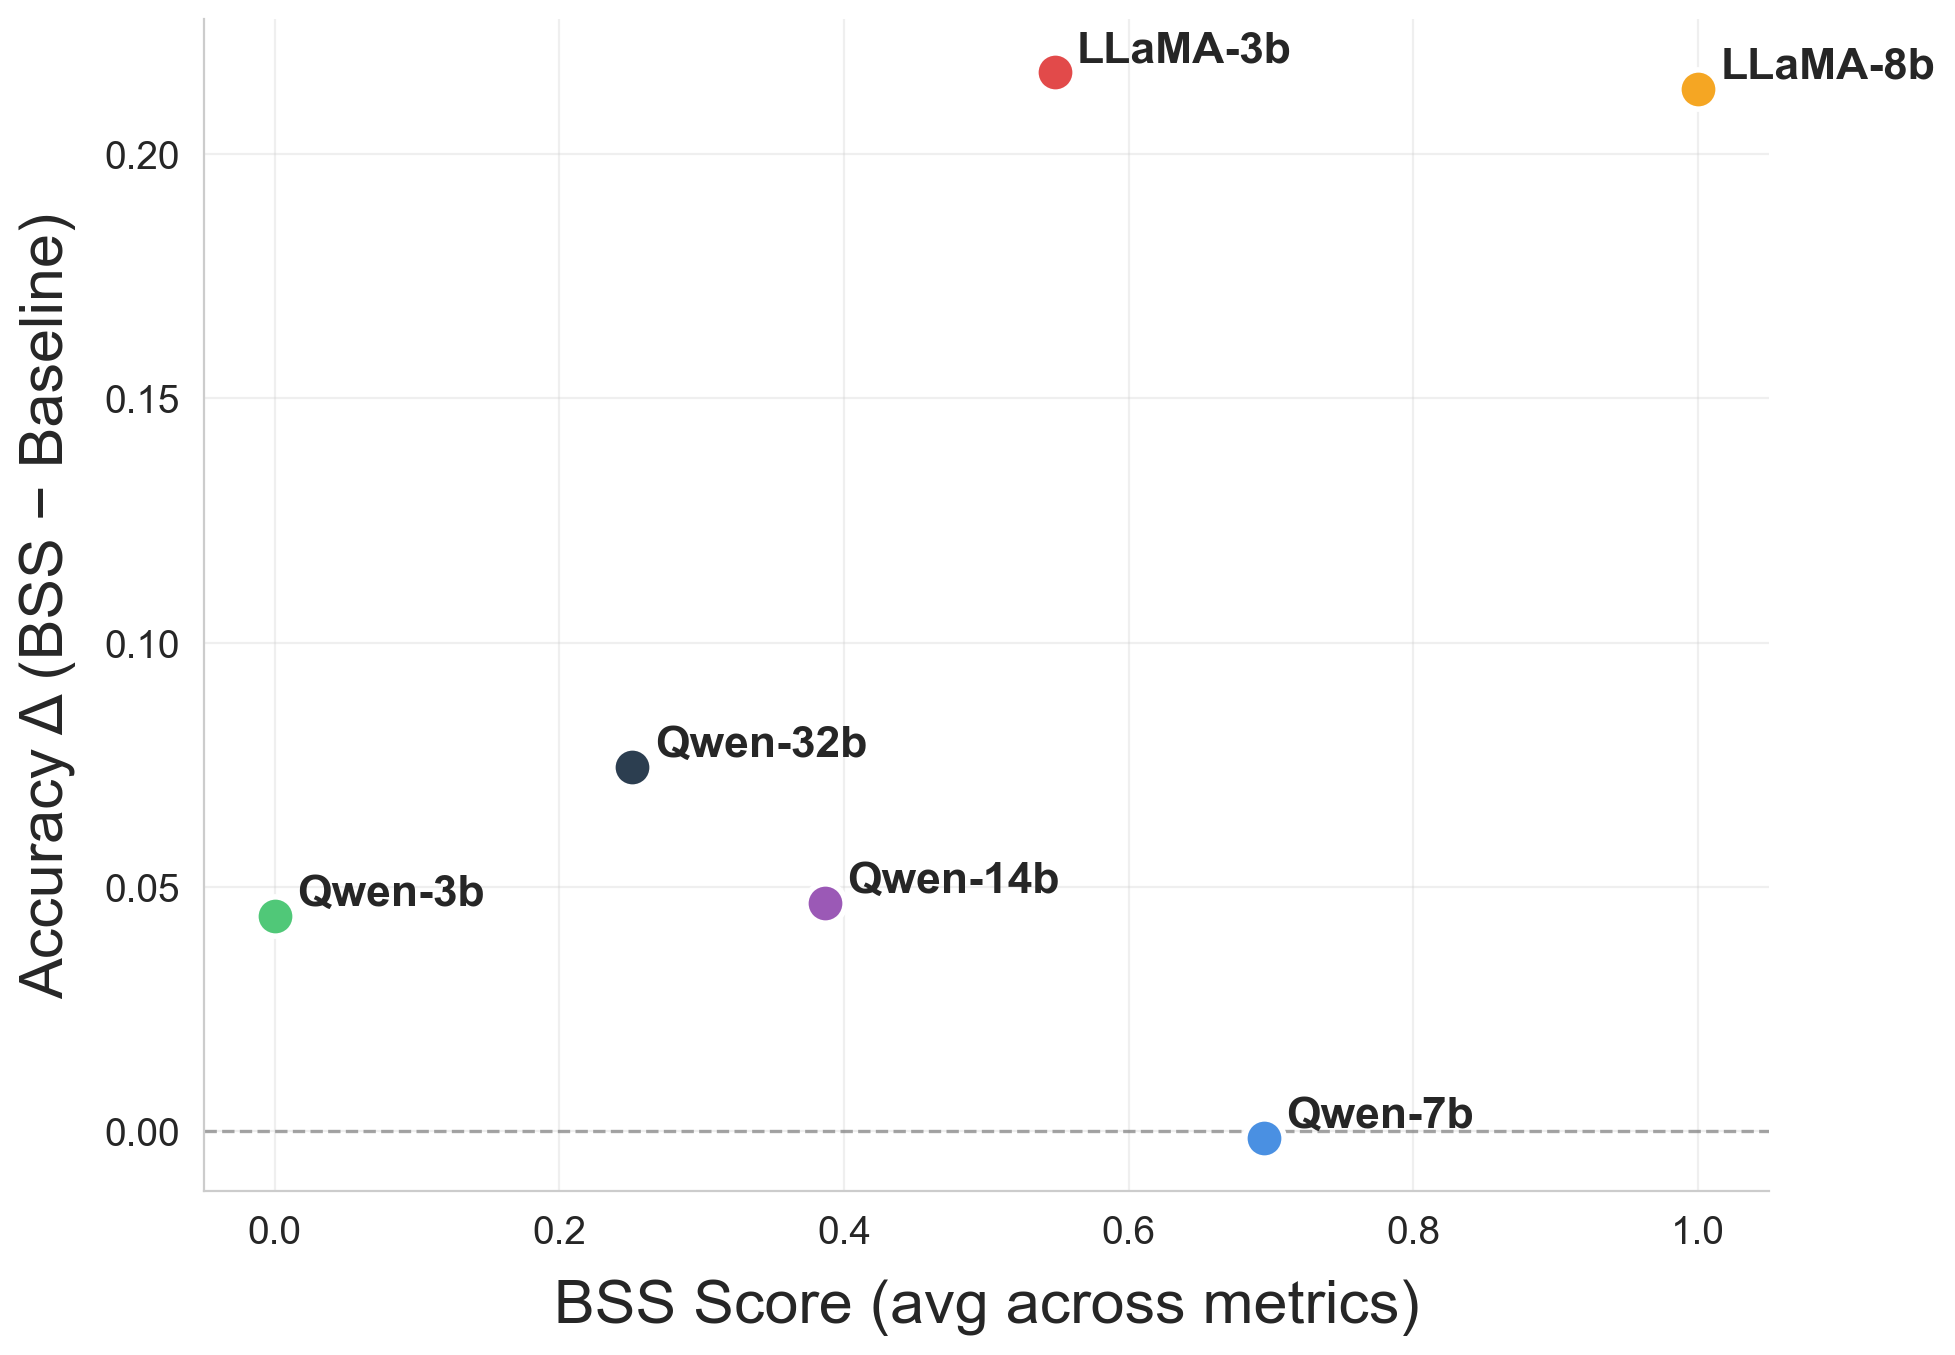

In [87]:
if "baseline" in accuracy and "bss" in accuracy and "bss" in bss_scores:
    base_acc = accuracy["baseline"].set_index("model")["accuracy"]
    bss_acc = accuracy["bss"].set_index("model")["accuracy"]
    scores_df = bss_scores["bss"]

    avg_bss = scores_df.groupby("model")["bss_score"].mean()

    models_both = [m for m in avg_bss.index if m in base_acc.index and m in bss_acc.index and m != "majority"]
    scatter_data = pd.DataFrame({
        "model": models_both,
        "bss_score": [avg_bss[m] for m in models_both],
        "delta": [(bss_acc[m] - base_acc[m]) for m in models_both],
    })

    fig, ax = plt.subplots(figsize=(10, 7))
    for _, row in scatter_data.iterrows():
        ax.scatter(row["bss_score"], row["delta"],
                   s=200, c=model_color(row["model"]), edgecolors="white", linewidth=2, zorder=5)
        model_display = row["model"].replace("llama", "LLaMA-").replace("qwen", "Qwen-")
        ax.annotate(model_display, (row["bss_score"], row["delta"]),
                    textcoords="offset points", xytext=(8, 4), fontsize=16, fontweight="bold")

    ax.axhline(0, color="grey", ls="--", lw=1.2, alpha=0.7)
    
    ax.set_xlabel("BSS Score (avg across metrics)", fontsize=22, labelpad=10)
    ax.set_ylabel("Accuracy Δ (BSS − Baseline)", fontsize=22, labelpad=10)
    
    # Fine-grained grid
    ax.grid(True, which="major", alpha=0.3, linestyle="-", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    
    # Enhanced tick styling
    ax.tick_params(labelsize=14, length=5, width=1.2)
    
    sns.despine()
    fig.tight_layout()
    fig.savefig(FIGS_DIR / "bss_score_vs_delta.pdf")
    fig.savefig(FIGS_DIR / "bss_score_vs_delta.png")
    plt.show()
else:
    print("Need both baseline and bss experiments with bss_scores.csv to plot this.")


## 12. Knowledge-Gated Accuracy

Accuracy restricted to samples where `knowledge_flags[model] == True` — i.e., the model "knew" the answer before debate.
Shows whether scores help models *hold onto* correct answers rather than being swayed.

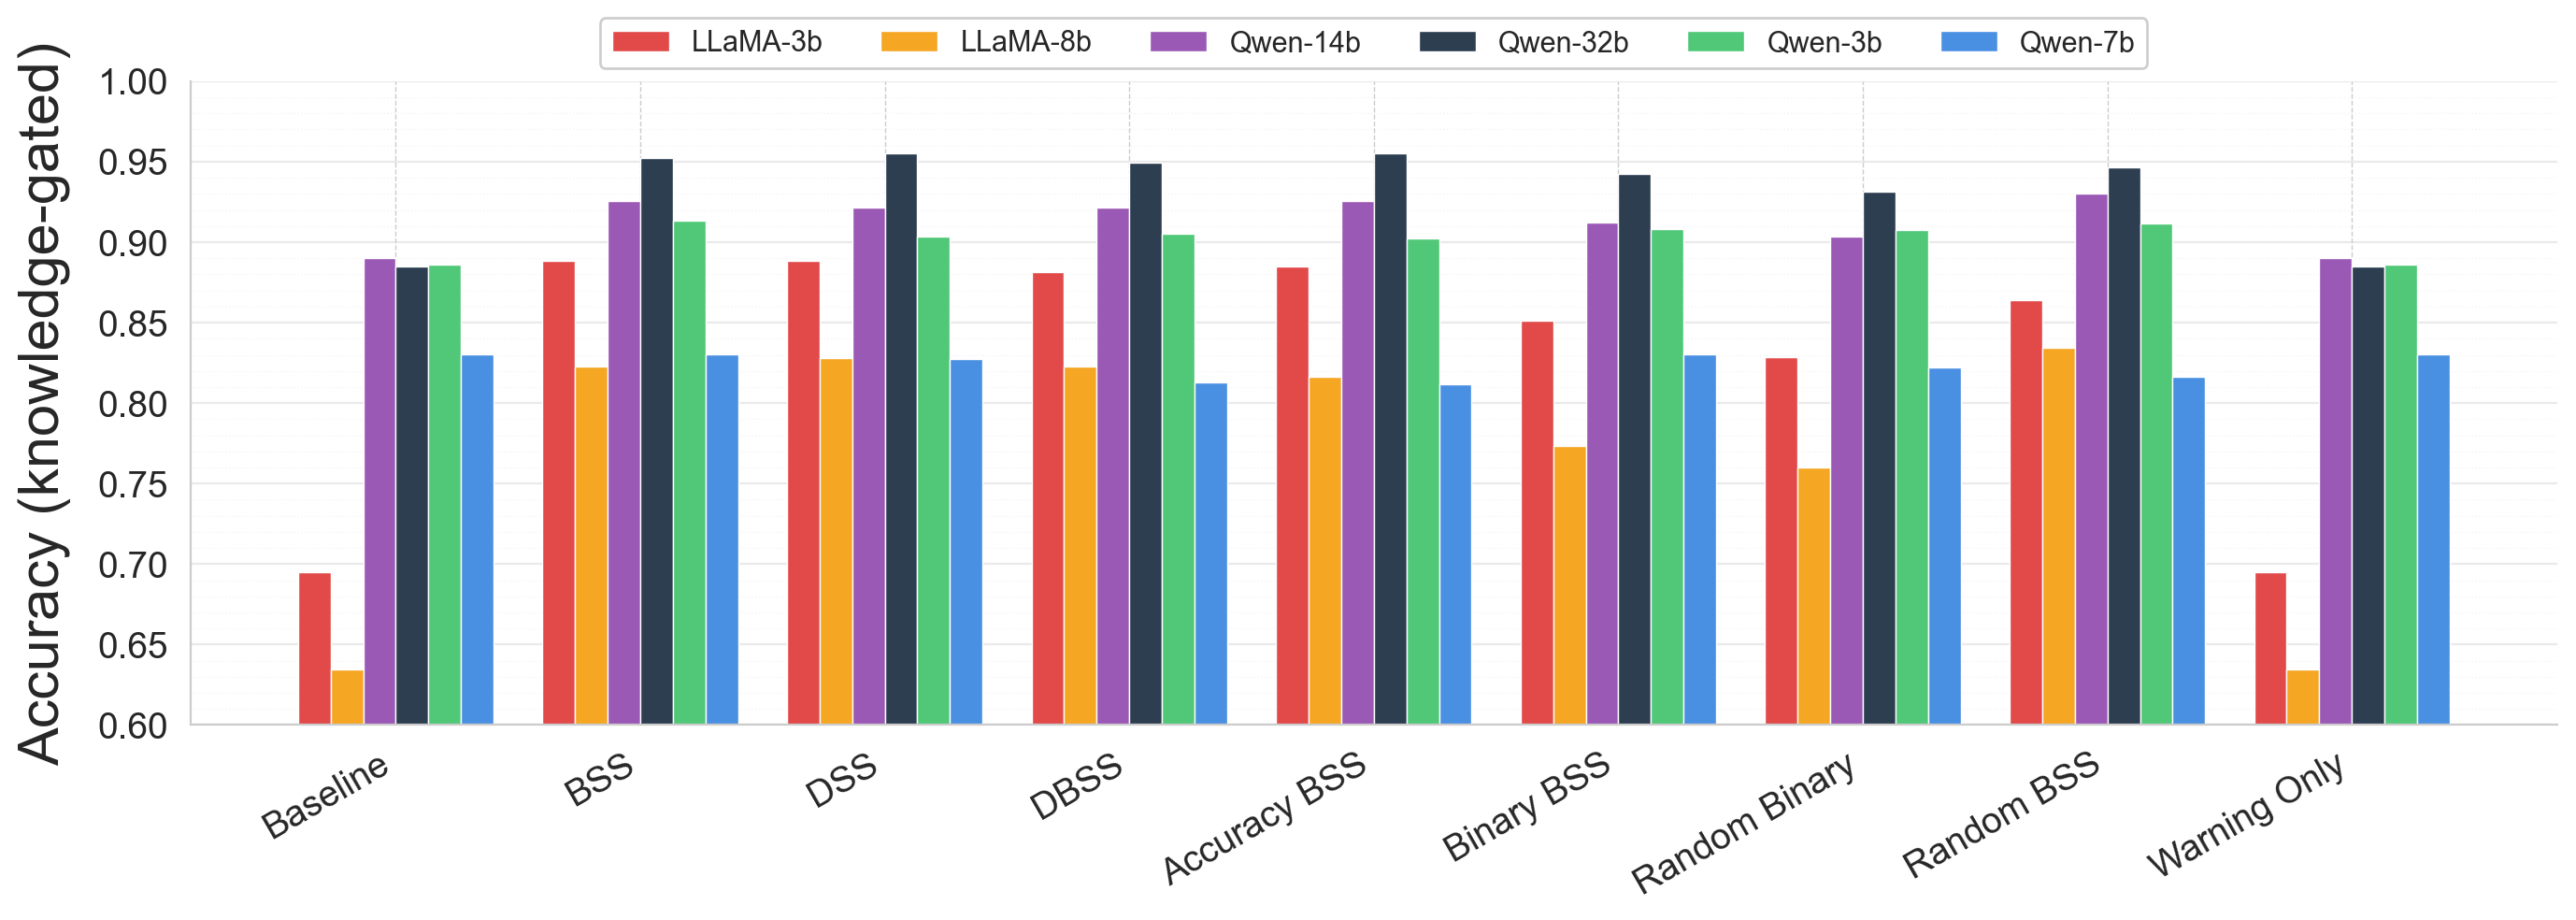

In [89]:
exps_kg = [e for e in EXPERIMENTS if e in knowledge_acc and not knowledge_acc[e].empty]
if exps_kg:
    kg_rows = []
    for exp in exps_kg:
        df = knowledge_acc[exp]
        for model, grp in df.groupby("model"):
            kg_rows.append({"experiment": exp, "model": model,
                            "accuracy": grp["is_correct"].mean(),
                            "n": len(grp)})
    kg_df = pd.DataFrame(kg_rows)
    models_kg = sorted(kg_df["model"].unique())

    fig, ax = plt.subplots(figsize=(14, 6.5))
    x = np.arange(len(exps_kg))
    width = 0.8 / max(len(models_kg), 1)

    for i, model in enumerate(models_kg):
        vals = []
        for exp in exps_kg:
            subset = kg_df[(kg_df["experiment"] == exp) & (kg_df["model"] == model)]
            vals.append(subset["accuracy"].values[0] if len(subset) else 0)
        ax.bar(x + i * width - 0.4 + width / 2, vals, width,
               label=model.replace("llama", "LLaMA-").replace("qwen", "Qwen-"), 
               color=model_color(model), edgecolor="white", lw=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels([NICE_NAMES.get(e, e) for e in exps_kg], rotation=30, ha="right", fontsize=14)
    ax.set_ylabel("Accuracy (knowledge-gated)", fontsize=22, labelpad=10)
    ax.set_ylim(0.6, 1.0)
    
    # Fine-grained y-axis ticks
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.05))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.01))
    
    # Enhanced gridlines (major and minor)
    ax.grid(True, which="major", axis="y", linestyle="-", alpha=0.4, linewidth=0.8, zorder=0)
    ax.grid(True, which="minor", axis="y", linestyle=":", alpha=0.2, linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    
    ax.tick_params(labelsize=14, length=5, width=1.2)
    ax.legend(ncol=len(models_kg), loc="upper center", bbox_to_anchor=(0.5, 1.12), framealpha=0.95)
    sns.despine()
    fig.tight_layout(rect=[0, 0, 1, 0.82])
    fig.savefig(FIGS_DIR / "knowledge_gated_accuracy.pdf")
    fig.savefig(FIGS_DIR / "knowledge_gated_accuracy.png")
    plt.show()
else:
    print("No knowledge_gated_accuracy.csv data found.")

## 13. Cumulative Flip Direction Over Rounds

Tracks how sycophantic vs correct flips accumulate as debate progresses. A healthy scoring mechanism should suppress sycophantic flips over rounds.

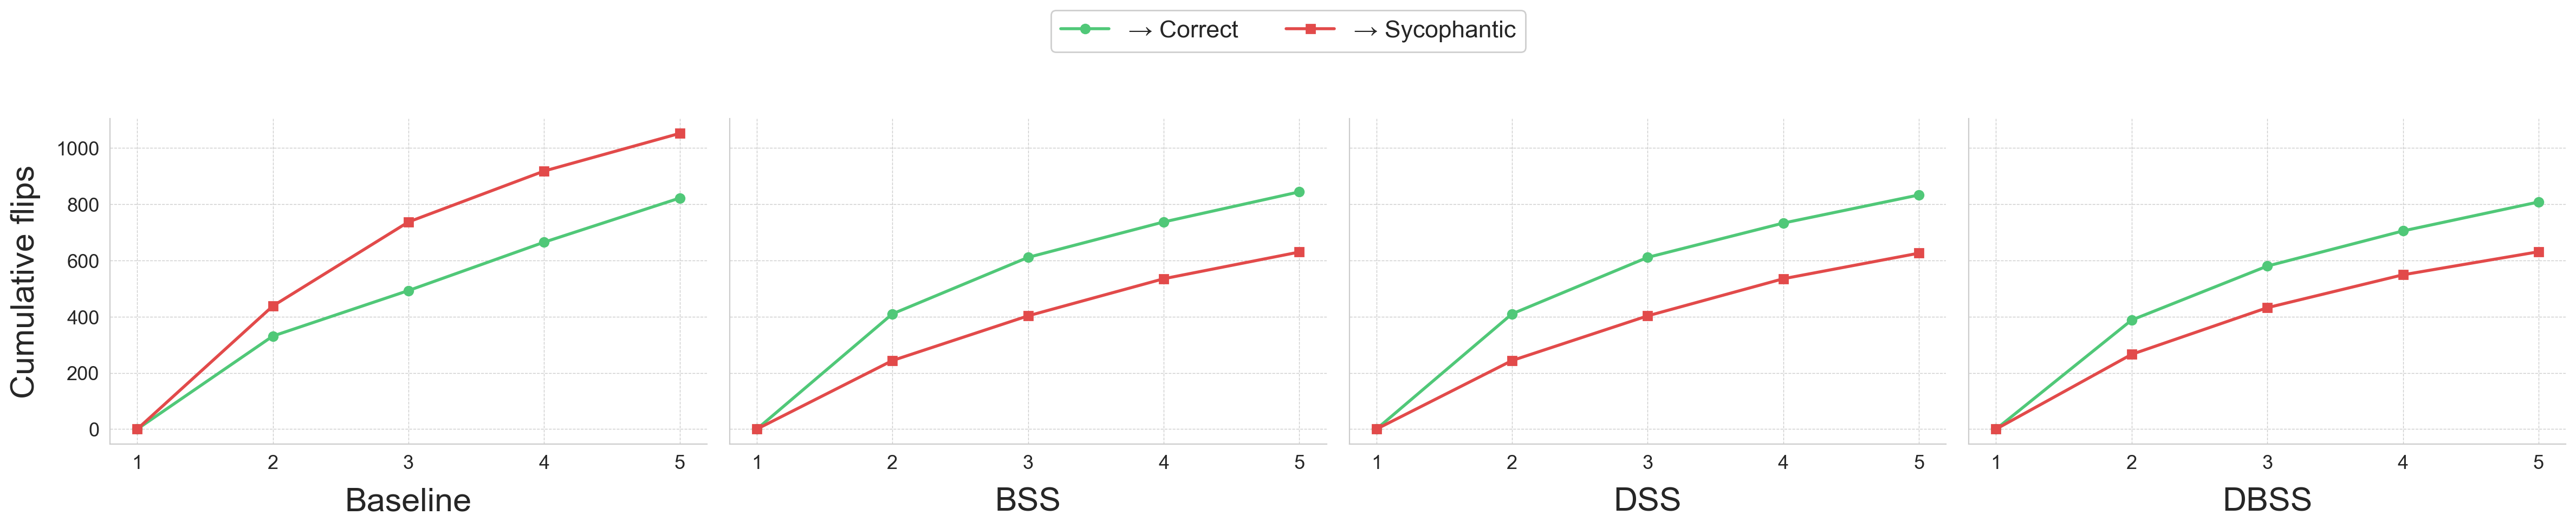

In [27]:
exps_flip_round = [e for e in ["baseline", "bss", "dss", "dbss"] if e in flip_raw and not flip_raw[e].empty and "round" in flip_raw[e].columns]
if exps_flip_round:
    n_exps = len(exps_flip_round)
    fig, axes = plt.subplots(1, n_exps, figsize=(6 * n_exps, 5), sharey=True, squeeze=False)
    axes = axes.flatten()

    for idx, exp in enumerate(exps_flip_round):
        ax = axes[idx]
        df = flip_raw[exp].copy()
        if "round" not in df.columns:
            continue
        max_round = int(df["round"].max())
        rounds = list(range(1, max_round + 1))

        cum_correct = []
        cum_syco = []
        for r in rounds:
            sub = df[df["round"] <= r]
            cum_correct.append(sub["toward_correct"].sum() if "toward_correct" in sub.columns else 0)
            cum_syco.append(sub["toward_sycophantic"].sum() if "toward_sycophantic" in sub.columns else 0)

        ax.plot(rounds, cum_correct, marker="o", label="→ Correct", color="#50C878", lw=2)
        ax.plot(rounds, cum_syco, marker="s", label="→ Sycophantic", color="#E24A4A", lw=2)
        ax.set_xlabel(NICE_NAMES.get(exp, exp), fontsize=22, labelpad=10)
        if idx == 0:
            ax.set_ylabel("Cumulative flips", fontsize=22, labelpad=10)
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        sns.despine(ax=ax)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=2, fontsize=16, **LEGEND_FIG_KW)

    fig.tight_layout(rect=[0, 0, 1, 0.82])
    fig.savefig(FIGS_DIR / "cumulative_flip_direction.pdf")
    fig.savefig(FIGS_DIR / "cumulative_flip_direction.png")
    plt.show()
else:
    print("No flip data with round info found.")


## 14. Flip Rate Breakdown (Per Model × Experiment)

Uses `flip_rates.csv` from **evaluate** (or `flip_summary.csv` from **analyze**). For eval, plots every rate column: **overall flip rate**, **toward correct**, **toward sycophantic**, **toward majority**. For analyze-only CSVs, rates are counts divided by `transitions`, plus **away from correct** when present.

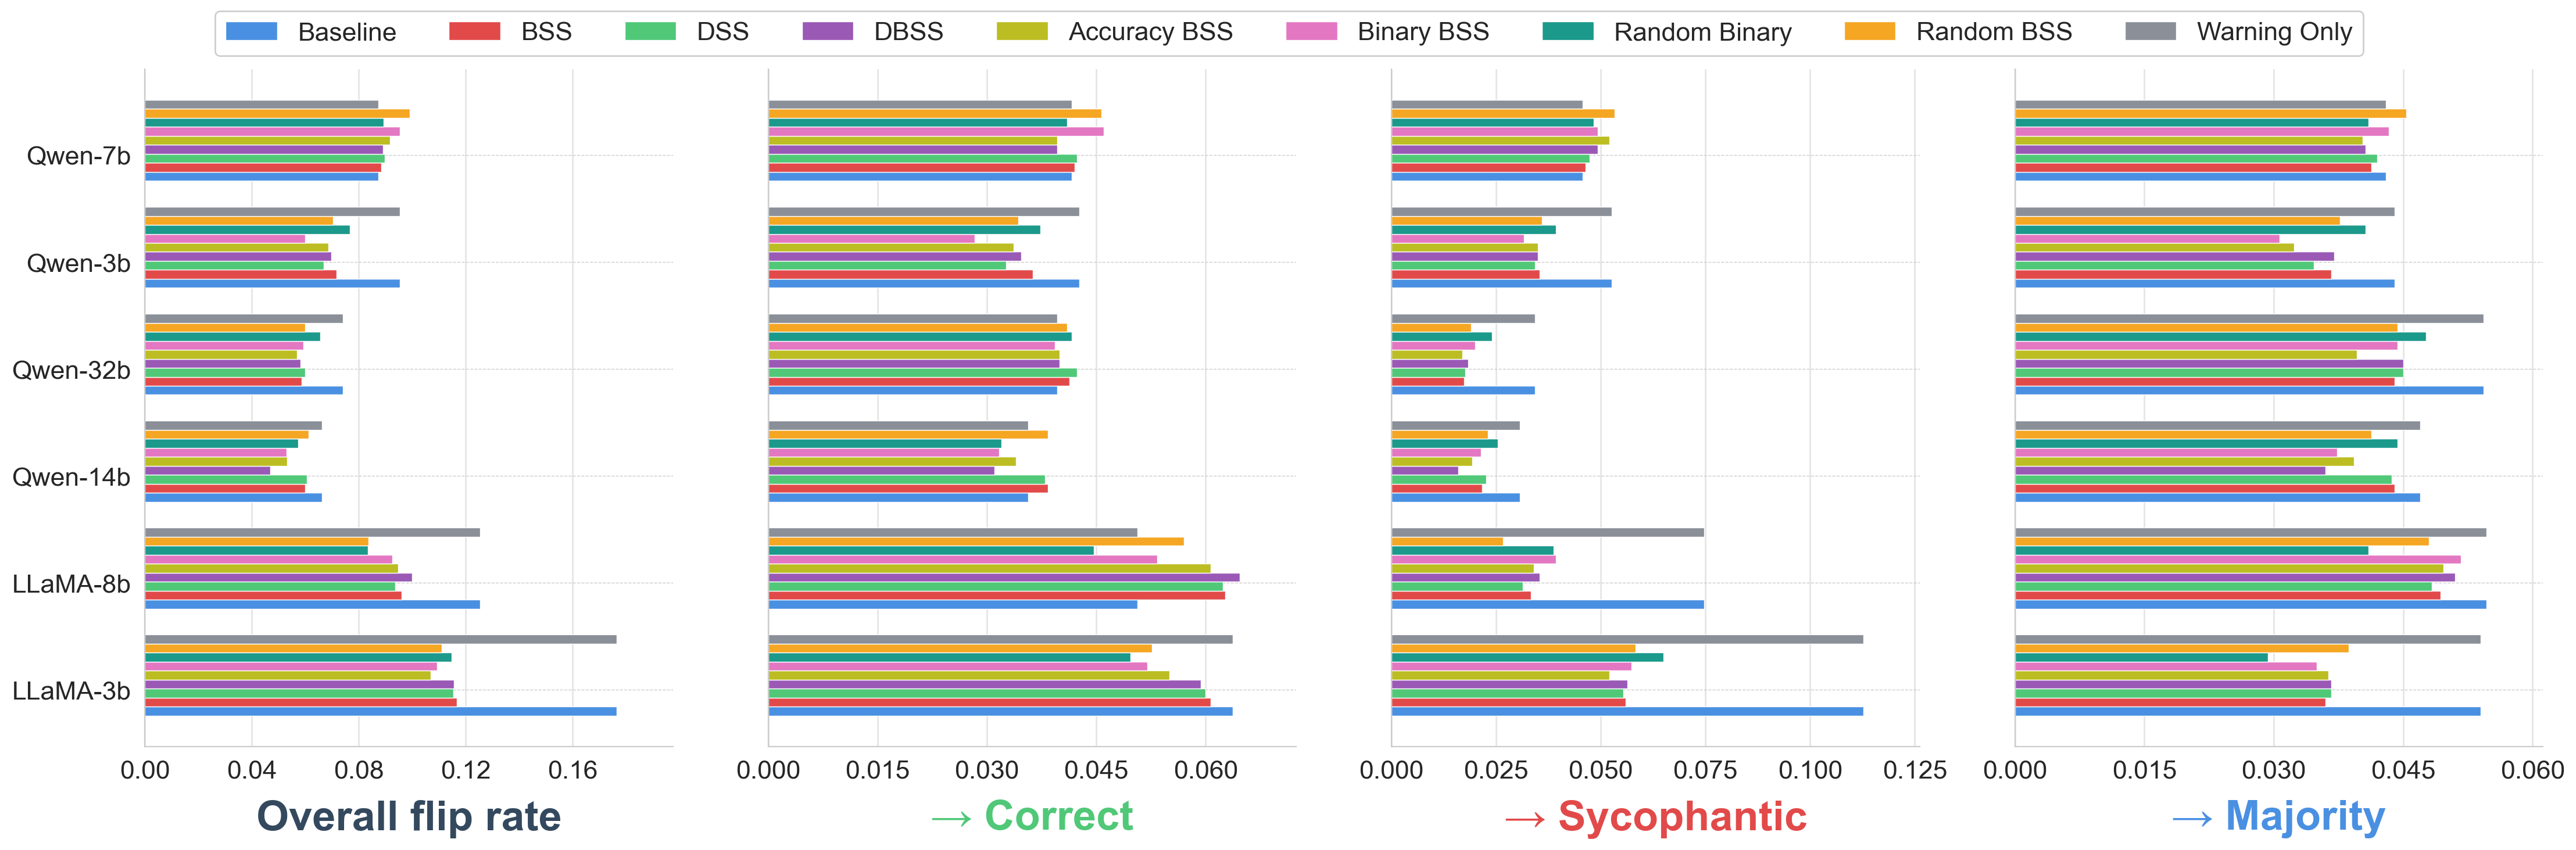

In [104]:
exps_fr = [e for e in EXPERIMENTS if e in flips and not flips[e].empty]
if exps_fr:
    _df0 = flips[exps_fr[0]]
    # evaluate.py: precomputed *_rate columns; analyze.py: counts + transitions
    if "toward_correct_rate" in _df0.columns:
        directions = [
            ("flip_rate", "Overall flip rate", "#34495e"),
            ("toward_correct_rate", "→ Correct", "#50C878"),
            ("toward_sycophantic_rate", "→ Sycophantic", "#E24A4A"),
            ("toward_majority_rate", "→ Majority", "#4A90E2"),
        ]
    else:
        directions = [
            ("flip_rate", "Overall flip rate", "#34495e"),
            ("toward_correct", "→ Correct", "#50C878"),
            ("toward_sycophantic", "→ Sycophantic", "#E24A4A"),
            ("toward_majority", "→ Majority", "#4A90E2"),
        ]

    def _flip_rate_for_row(row, col, transitions):
        if col.endswith("_rate") or col == "flip_rate":
            return float(row[col])
        return float(row[col]) / transitions if transitions else 0.0

    rate_rows = []
    for exp in exps_fr:
        df = flips[exp].copy()
        for _, row in df.iterrows():
            model = row["model"]
            trans = int(row.get("transitions", 0) or 0)
            for col, label, _ in directions:
                rate_rows.append({
                    "experiment": exp,
                    "model": model,
                    "direction": label,
                    "metric": col,
                    "rate": _flip_rate_for_row(row, col, trans),
                })
    rate_df = pd.DataFrame(rate_rows)

    models_list = sorted(rate_df["model"].unique())
    n_models = len(models_list)
    n_dirs = len(directions)

    fig, axes = plt.subplots(1, n_dirs, figsize=(5.6 * n_dirs, max(8.0, n_models * 1.05)),
                             sharey=True, squeeze=False)
    axes = axes.flatten()

    for d_idx, (col, label, base_color) in enumerate(directions):
        ax = axes[d_idx]
        sub = rate_df[rate_df["metric"] == col]
        y = np.arange(n_models) * 1.65
        bar_h = 1.25 / max(len(exps_fr), 1)
        xmax = max(sub["rate"].max() * 1.12, 0.02) if len(sub) else 0.1
        xmax = min(xmax, 1.0)

        for e_idx, exp in enumerate(exps_fr):
            edf = sub[sub["experiment"] == exp].set_index("model")
            vals = [edf.loc[m, "rate"] if m in edf.index else 0 for m in models_list]
            ax.barh(y + e_idx * bar_h - 0.4 + bar_h / 2, vals, bar_h,
                    label=NICE_NAMES.get(exp, exp), color=exp_color(exp),
                    edgecolor="white", lw=0.5)

        ax.set_yticks(y)
        ax.set_yticklabels([m.replace("llama", "LLaMA-").replace("qwen", "Qwen-") for m in models_list], fontsize=14)
        ax.set_xlabel(label, fontsize=26, labelpad=10, fontweight="bold", color=base_color)
        ax.set_xlim(0, xmax)
        ax.xaxis.set_major_locator(plt.MaxNLocator(6))
        ax.grid(True, which="major", axis="x", linestyle="-", alpha=0.5, linewidth=1.0, zorder=0)
        ax.set_axisbelow(True)
        ax.tick_params(labelsize=16, length=5, width=1.2)
        sns.despine(ax=ax)

    handles, labels_l = axes[0].get_legend_handles_labels()
    # Lower bbox_to_anchor y moves legend down (1 = top of figure).
    fig.legend(
        handles, labels_l, ncol=len(exps_fr), fontsize=16,
        loc="upper center", bbox_to_anchor=(0.5, 0.93), framealpha=0.95,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.88])
    fig.subplots_adjust(wspace=0.18)
    fig.savefig(FIGS_DIR / "flip_rate_by_direction.pdf")
    fig.savefig(FIGS_DIR / "flip_rate_by_direction.png")
    plt.show()
else:
    print("No flip_summary / flip_rates data found.")


## 15. Subject × model: accuracy Δ vs Baseline (ablations)

**2×4 grid**: row 1 = Baseline (absolute accuracy), BSS, DSS, DBSS; row 2 = Accuracy BSS, Binary BSS, Random BSS, Random Binary. **Top-left** shows **baseline absolute accuracy**; all other panels show **Δ = condition accuracy − baseline**. Delta panels share one symmetric *y*-range; the baseline panel uses its own *y*-range (~0.4–1.0). Abbreviated *x* labels; *y*-axis label on the leftmost visible panel per row (`Absolute accuracy` vs `Accuracy Δ (condition − Baseline)`). Figures: `subject_accuracy_delta_vs_baseline_grid2x4.{pdf,png}`.

Requires `subject_accuracy.csv` from `analyze.py` for baseline and each condition you want shown. Panels with missing CSVs are hidden.

**Re-run `python analyze.py --all`** after pulling changes so per-subject accuracy files exist.


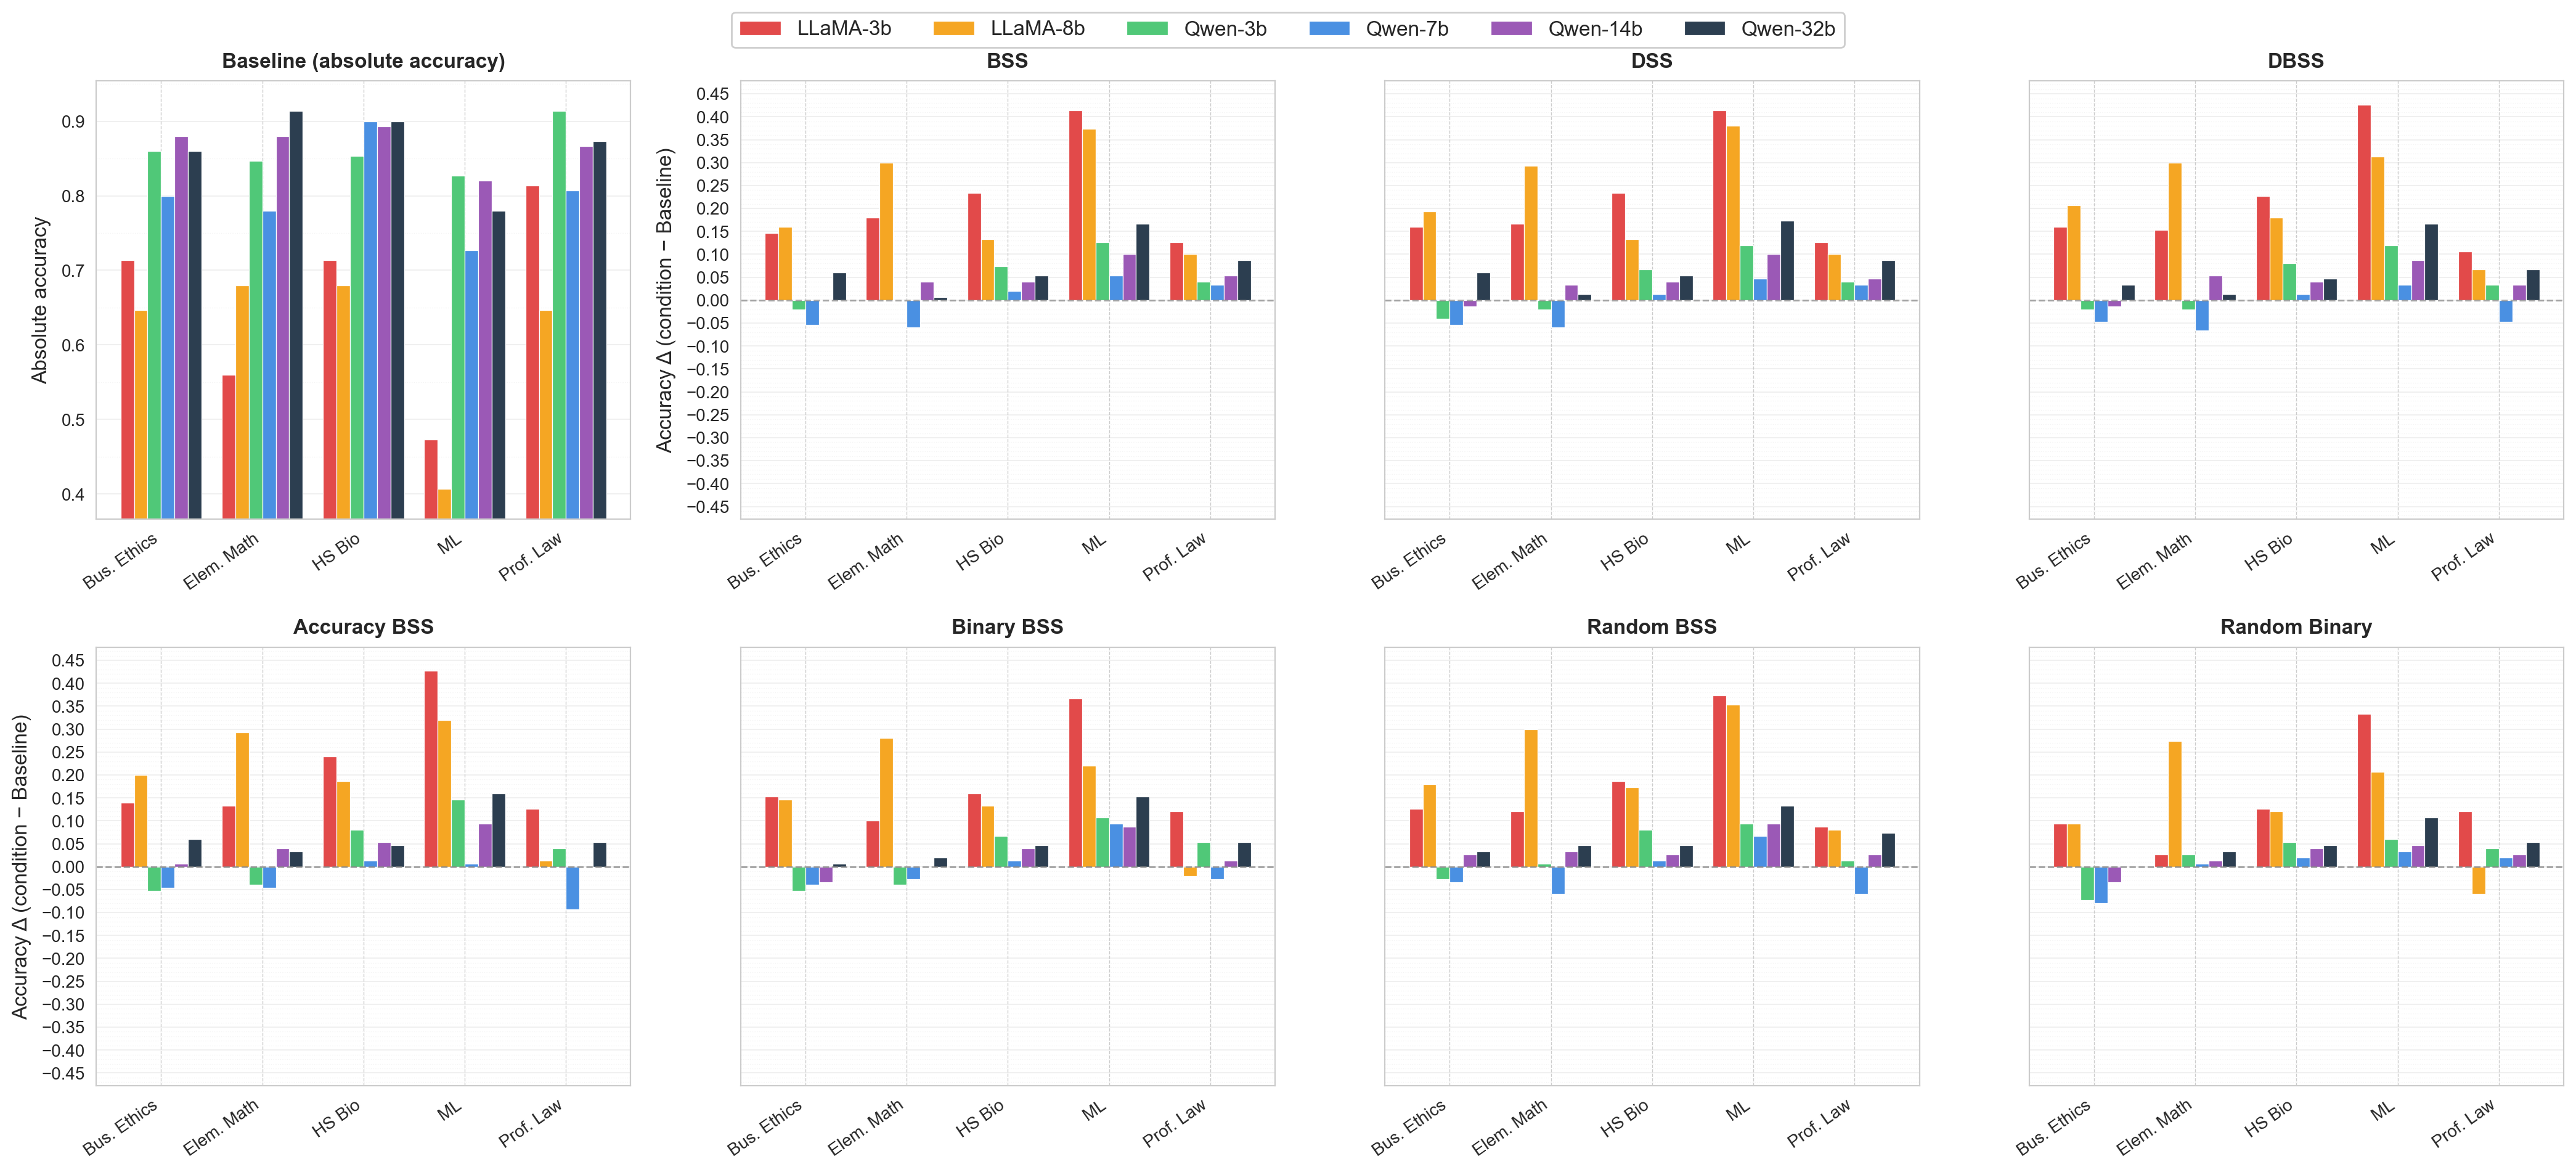

In [25]:
MODELS_NO_MAJ = [m for m in MODEL_ORDER if m != "majority"]

SUBJECT_SHORT = {
    "business_ethics": "Bus. Ethics",
    "elementary_mathematics": "Elem. Math",
    "high_school_biology": "HS Bio",
    "machine_learning": "ML",
    "professional_law": "Prof. Law",
}

# 2×4: baseline = absolute accuracy; others = Δ vs baseline
PANEL_GRID = [
    ["baseline", "bss", "dss", "dbss"],
    ["accuracy_bss", "binary_bss", "random_bss", "random_binary"],
]
DELTA_PANEL_ORDER = [e for row in PANEL_GRID for e in row]


def _merged_delta_vs_baseline(sa_base, exp):
    """Merge baseline with condition `exp`; returns None if missing or empty."""
    if exp == "baseline":
        return None
    trt = subject_acc.get(exp)
    if trt is None:
        return None
    merged = sa_base.merge(
        trt, on=["subject", "model"], suffixes=("_base", "_trt"), how="inner"
    )
    if merged.empty:
        return None
    merged = merged.copy()
    merged["delta"] = merged["accuracy_trt"] - merged["accuracy_base"]
    return merged


if "baseline" not in subject_acc:
    print("Need baseline subject_accuracy.csv (run analyze.py).")
else:
    sa_base = subject_acc["baseline"]
    merged_by_exp = {}
    for exp in DELTA_PANEL_ORDER:
        if exp == "baseline":
            continue
        m = _merged_delta_vs_baseline(sa_base, exp)
        if m is not None:
            merged_by_exp[exp] = m

    acc_vals = [
        float(v)
        for v in sa_base["accuracy"]
        if pd.notna(v) and np.isfinite(v)
    ]
    if not acc_vals:
        print("Baseline subject_accuracy has no valid accuracy values.")
    else:
        lo, hi = min(acc_vals), max(acc_vals)
        pad = max(0.02, (hi - lo) * 0.08)
        y_abs_lo = max(0.0, lo - pad)
        y_abs_hi = min(1.0, hi + pad)

        all_abs_d = []
        for merged in merged_by_exp.values():
            for v in merged["delta"]:
                if pd.notna(v) and np.isfinite(v):
                    all_abs_d.append(abs(float(v)))
        y_lim_delta = max(0.05, (max(all_abs_d) if all_abs_d else 0.05) * 1.12)

        fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharey=False, squeeze=False)

        axes_by_exp = {}
        for r in range(2):
            for c in range(4):
                exp = PANEL_GRID[r][c]
                axes_by_exp[exp] = axes[r, c]

        legend_handles = None
        legend_labels = None

        def _short_subject(s):
            return SUBJECT_SHORT.get(s, s.replace("_", " ")[:12])

        for exp, ax in axes_by_exp.items():
            if exp == "baseline":
                subjects = sorted(sa_base["subject"].unique())
                models = [m for m in MODELS_NO_MAJ if m in set(sa_base["model"].unique())]
                if not models:
                    models = sorted(m for m in sa_base["model"].unique() if m != "majority")
                x = np.arange(len(subjects))
                n_m = len(models)
                width = 0.8 / max(n_m, 1)
                for i, model in enumerate(models):
                    mdata = sa_base[sa_base["model"] == model].set_index("subject")
                    vals = [
                        float(mdata.loc[s, "accuracy"]) if s in mdata.index else np.nan
                        for s in subjects
                    ]
                    model_display = model.replace("llama", "LLaMA-").replace("qwen", "Qwen-")
                    ax.bar(
                        x + i * width - 0.4 + width / 2,
                        vals,
                        width,
                        label=model_display,
                        color=model_color(model),
                        edgecolor="white",
                        lw=0.45,
                    )
                ax.set_ylim(y_abs_lo, y_abs_hi)
                ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
                ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))
                ax.set_title(
                    "Baseline (absolute accuracy)", fontsize=12, fontweight="bold", pad=8
                )
            else:
                if exp not in merged_by_exp:
                    ax.set_visible(False)
                    continue
                merged = merged_by_exp[exp]
                subjects = sorted(merged["subject"].unique())
                models = [m for m in MODELS_NO_MAJ if m in set(merged["model"].unique())]
                if not models:
                    models = sorted(m for m in merged["model"].unique() if m != "majority")
                x = np.arange(len(subjects))
                n_m = len(models)
                width = 0.8 / max(n_m, 1)
                for i, model in enumerate(models):
                    mdata = merged[merged["model"] == model].set_index("subject")
                    deltas = [
                        float(mdata.loc[s, "delta"]) if s in mdata.index else np.nan
                        for s in subjects
                    ]
                    model_display = model.replace("llama", "LLaMA-").replace("qwen", "Qwen-")
                    ax.bar(
                        x + i * width - 0.4 + width / 2,
                        deltas,
                        width,
                        label=model_display,
                        color=model_color(model),
                        edgecolor="white",
                        lw=0.45,
                    )
                dmax = float(merged["delta"].abs().max())
                if dmax < 1e-12:
                    ax.text(
                        0.5,
                        0.5,
                        "Identical to baseline — all Δ = 0\n(zero-height bars)",
                        transform=ax.transAxes,
                        ha="center",
                        va="center",
                        fontsize=10,
                        color="0.35",
                    )
                ax.axhline(0, color="grey", ls="--", lw=1.0, alpha=0.7, zorder=1)
                ax.set_ylim(-y_lim_delta, y_lim_delta)
                ax.yaxis.set_major_locator(plt.MultipleLocator(0.05))
                ax.yaxis.set_minor_locator(plt.MultipleLocator(0.01))
                ax.set_title(NICE_NAMES.get(exp, exp), fontsize=12, fontweight="bold", pad=8)

            ax.set_xticks(x)
            ax.set_xticklabels(
                [_short_subject(s) for s in subjects],
                rotation=35,
                ha="right",
                fontsize=9,
            )
            ax.grid(True, which="major", axis="y", linestyle="-", alpha=0.35, linewidth=0.6, zorder=0)
            ax.grid(True, which="minor", axis="y", linestyle=":", alpha=0.2, linewidth=0.5, zorder=0)
            ax.set_axisbelow(True)
            ax.tick_params(labelsize=10, length=3, width=0.9)

            if legend_handles is None:
                legend_handles, legend_labels = ax.get_legend_handles_labels()

        for r in range(2):
            left_done = False
            for c in range(4):
                exp = PANEL_GRID[r][c]
                ax = axes[r, c]
                if not ax.get_visible():
                    continue
                if (not left_done) or exp == "bss":
                    if exp == "baseline":
                        ax.set_ylabel("Absolute accuracy", fontsize=12, labelpad=6)
                    else:
                        ax.set_ylabel(
                            "Accuracy Δ (condition − Baseline)",
                            fontsize=12,
                            labelpad=6,
                        )
                    ax.tick_params(axis="y", labelleft=True)
                    if not left_done:
                        left_done = True
                else:
                    ax.tick_params(axis="y", labelleft=False)

        fig.tight_layout(rect=[0.02, 0.03, 0.98, 0.97])

        if legend_handles:
            fig.legend(
                legend_handles,
                legend_labels,
                loc="upper center",
                bbox_to_anchor=(0.5, 0.99),
                ncol=min(len(legend_labels), 6),
                fontsize=12,
                framealpha=0.95,
            )

        stem = "subject_accuracy_delta_vs_baseline_grid2x4"
        fig.savefig(FIGS_DIR / f"{stem}.pdf")
        fig.savefig(FIGS_DIR / f"{stem}.png")
        plt.show()


## 16. Post-discussion sycophancy: per subject × model

Uses `per_subject_post_sycophancy.csv` (from `analyze.py`). **2×4 grid** (same experiment order as §15): row 1 = Baseline, BSS, DSS, DBSS; row 2 = Accuracy BSS, Binary BSS, Random BSS, Random Binary. Shared *y* (≈0–0.65). Abbreviated x labels; y-axis label on the leftmost visible panel per row. Default metric **sycophant_with_knowledge**. Figures: `subject_post_sycophancy_<metric>_grid2x4.{pdf,png}`.


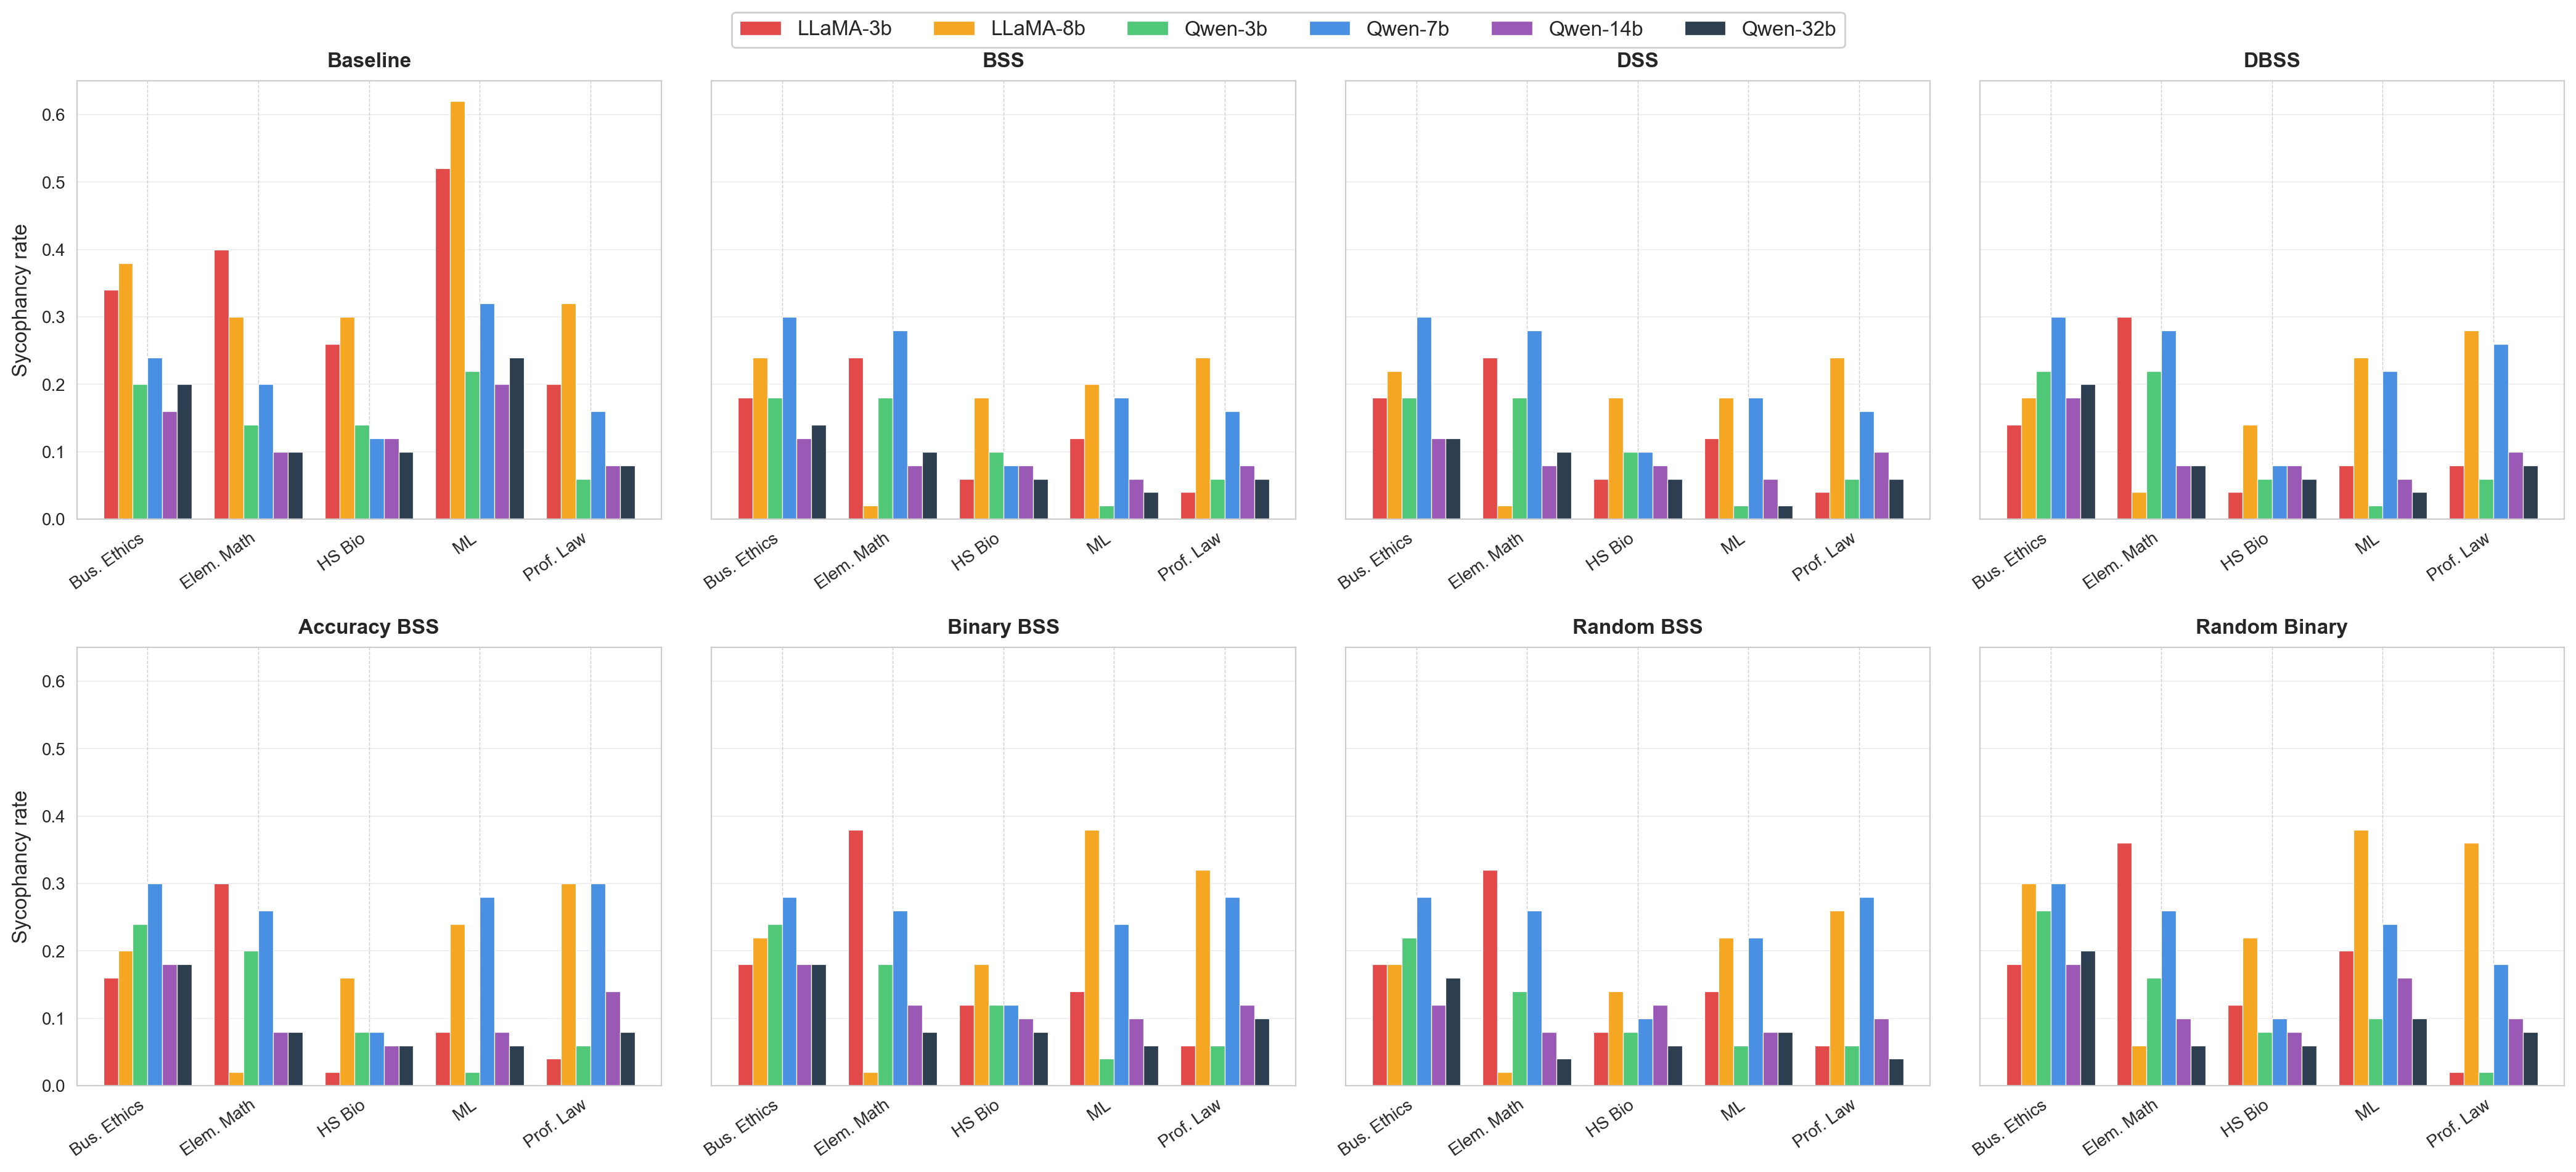

In [22]:
SYCO_METRIC_SUBJ = "sycophant_with_knowledge"
MODELS_NO_MAJ = [m for m in MODEL_ORDER if m != "majority"]

SUBJECT_SHORT = {
    "business_ethics": "Bus. Ethics",
    "elementary_mathematics": "Elem. Math",
    "high_school_biology": "HS Bio",
    "machine_learning": "ML",
    "professional_law": "Prof. Law",
}

# 2×4 (aligned with §15 accuracy-Δ grid)
PANEL_GRID = [
    ["baseline", "bss", "dss", "dbss"],
    ["accuracy_bss", "binary_bss", "random_bss", "random_binary"],
]
SYCO_PANEL_ORDER = [e for row in PANEL_GRID for e in row]

EXPS_WITH_SYCO = set()
for exp in EXPERIMENTS:
    if exp not in subject_post_syco:
        continue
    df = subject_post_syco[exp]
    sub = df[df["metric"] == SYCO_METRIC_SUBJ]
    if not sub.empty:
        EXPS_WITH_SYCO.add(exp)
    else:
        alts = df["metric"].dropna().unique().tolist()
        if alts:
            print(
                f"Skip {exp} in grid: no rows for {SYCO_METRIC_SUBJ!r}. "
                f"Available (sample): {alts[:4]}"
            )

if not EXPS_WITH_SYCO:
    print("No per-subject post-sycophancy data for this metric (re-run analyze.py).")
else:
    fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharey=True, squeeze=False)

    axes_by_exp = {}
    for r in range(2):
        for c in range(4):
            exp = PANEL_GRID[r][c]
            axes_by_exp[exp] = axes[r, c]

    all_vals_global = []
    for exp in SYCO_PANEL_ORDER:
        if exp not in EXPS_WITH_SYCO:
            continue
        df = subject_post_syco[exp]
        sub = df[df["metric"] == SYCO_METRIC_SUBJ]
        for _, row in sub.iterrows():
            v = row["post_syco"]
            if pd.notna(v) and np.isfinite(v):
                all_vals_global.append(float(v))
    data_max = max(all_vals_global) if all_vals_global else 0.4
    y_top = min(0.65, max(0.38, data_max * 1.1))

    legend_handles = None
    legend_labels = None

    def _short_subject(s):
        return SUBJECT_SHORT.get(s, s.replace("_", " ")[:12])

    for exp, ax in axes_by_exp.items():
        if exp not in EXPS_WITH_SYCO:
            ax.set_visible(False)
            continue

        df = subject_post_syco[exp]
        sub = df[df["metric"] == SYCO_METRIC_SUBJ].copy()
        subjects = sorted(sub["subject"].unique())
        models = [m for m in MODELS_NO_MAJ if m in set(sub["model"].unique())]

        x = np.arange(len(subjects))
        n_m = len(models)
        width = 0.8 / max(n_m, 1)

        for i, model in enumerate(models):
            mdata = sub[sub["model"] == model].set_index("subject")
            vals = [
                float(mdata.loc[s, "post_syco"]) if s in mdata.index else np.nan
                for s in subjects
            ]
            model_display = model.replace("llama", "LLaMA-").replace("qwen", "Qwen-")
            ax.bar(
                x + i * width - 0.4 + width / 2,
                vals,
                width,
                label=model_display,
                color=model_color(model),
                edgecolor="white",
                lw=0.45,
            )

        ax.set_ylim(0, y_top)
        ax.set_xticks(x)
        ax.set_xticklabels(
            [_short_subject(s) for s in subjects], rotation=35, ha="right", fontsize=9
        )
        ax.set_title(NICE_NAMES.get(exp, exp), fontsize=12, fontweight="bold", pad=8)
        ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
        ax.grid(True, which="major", axis="y", linestyle="-", alpha=0.35, linewidth=0.6, zorder=0)
        ax.set_axisbelow(True)
        ax.tick_params(labelsize=10, length=3, width=0.9)

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

    for r in range(2):
        left_done = False
        for c in range(4):
            ax = axes[r, c]
            if not ax.get_visible():
                continue
            if not left_done:
                ax.set_ylabel("Sycophancy rate", fontsize=12, labelpad=6)
                ax.tick_params(axis="y", labelleft=True)
                left_done = True
            else:
                ax.tick_params(axis="y", labelleft=False)

    fig.tight_layout(rect=[0.02, 0.03, 0.98, 0.97])

    if legend_handles:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.99),
            ncol=min(len(legend_labels), 6),
            fontsize=12,
            framealpha=0.95,
        )
    stem = f"subject_post_sycophancy_{SYCO_METRIC_SUBJ}_grid2x4"
    fig.savefig(FIGS_DIR / f"{stem}.pdf")
    fig.savefig(FIGS_DIR / f"{stem}.png")
    plt.show()


## 17. Flip direction per subject (correct vs sycophantic)

From `per_subject_flip_direction.csv`: per MMLU subject, toward-correct and toward-sycophantic flip counts pooled over models. **Bar height = min(ratio, RATIO_CAP)** with ratio = correct / sycophantic (no sycophantic flips but some correct → drawn at cap). Dashed line at 1 = equal counts.


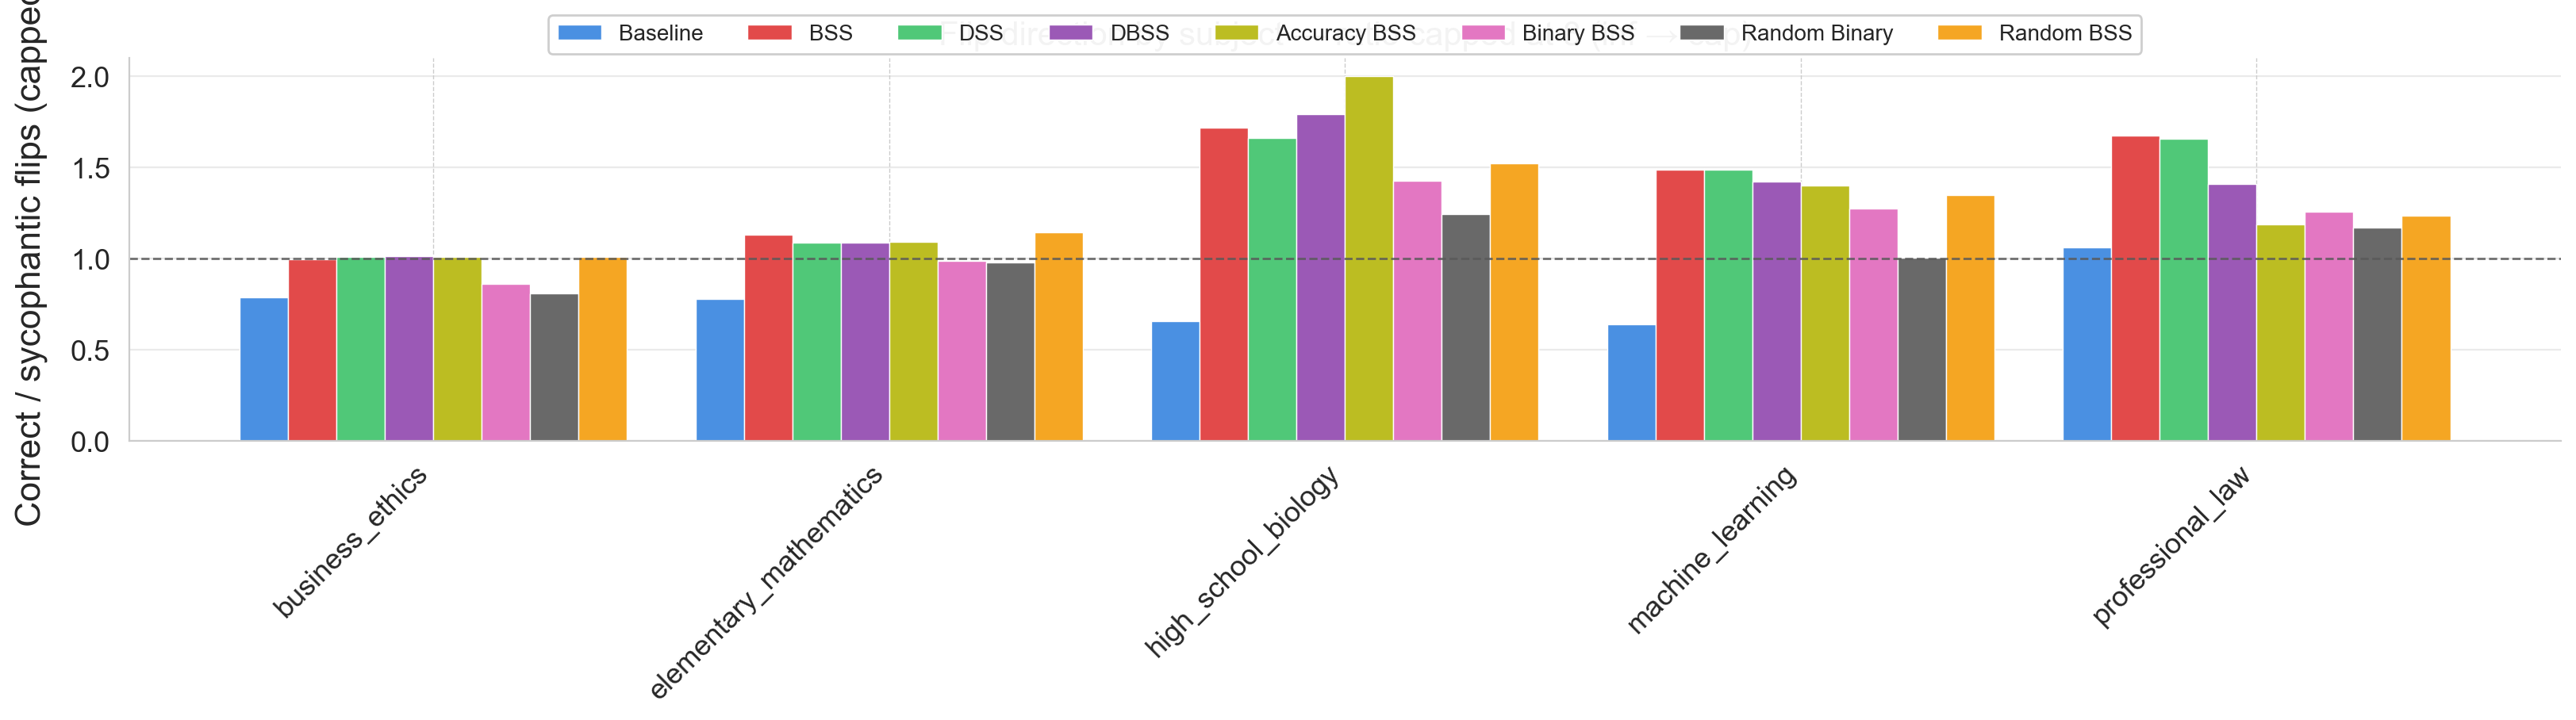

In [26]:
FLIP_EXPS = [e for e in EXPERIMENTS if e in subject_flip_dir and not subject_flip_dir[e].empty]
RATIO_CAP = 8.0

if FLIP_EXPS:
    subjects = sorted(
        set().union(*[set(subject_flip_dir[e]["subject"]) for e in FLIP_EXPS])
    )
    n_e = len(FLIP_EXPS)
    fig, ax = plt.subplots(figsize=(max(18, len(subjects) * 1.0, n_e * 1.2), 7))
    x = np.arange(len(subjects))
    width = 0.85 / max(n_e, 1)

    for i, exp in enumerate(FLIP_EXPS):
        edf = subject_flip_dir[exp].set_index("subject")
        ratios = []
        for s in subjects:
            if s not in edf.index:
                ratios.append(np.nan)
                continue
            r = edf.loc[s, "ratio_correct_over_sycophantic"]
            if np.isinf(r):
                ratios.append(RATIO_CAP)
            elif pd.isna(r):
                ratios.append(np.nan)
            else:
                ratios.append(min(float(r), RATIO_CAP))

        ax.bar(
            x + i * width,
            ratios,
            width,
            label=NICE_NAMES.get(exp, exp),
            color=exp_color(exp),
            edgecolor="white",
            linewidth=0.5,
        )

    ax.axhline(1.0, color="0.35", ls="--", lw=1.0, alpha=0.85)
    ax.set_xticks(x + width * (n_e - 1) / 2)
    ax.set_xticklabels(subjects, rotation=45, ha="right", fontsize=11)
    ax.set_ylabel("Correct / sycophantic flips (capped)", fontsize=16, labelpad=10)
    ax.set_title(
        f"Flip direction by subject — ratio capped at {RATIO_CAP:g} (inf → cap)",
        fontsize=15,
    )
    ax.grid(True, which="major", axis="y", linestyle="-", alpha=0.4, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=13, length=5, width=1.2)
    ax.legend(
        ncol=n_e,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.14),
        fontsize=10,
        framealpha=0.95,
    )
    sns.despine()
    fig.tight_layout(rect=[0.06, 0.12, 0.98, 0.86])
    fig.savefig(FIGS_DIR / "subject_flip_correct_over_sycophantic.pdf")
    fig.savefig(FIGS_DIR / "subject_flip_correct_over_sycophantic.png")
    plt.show()
else:
    print("No per_subject_flip_direction.csv (re-run analyze.py).")
